# 📊 DVA Lab — Social Media Data Analysis
## Reddit Comments Dataset (1 Million → 3 Lakh Subset)
### Dataset: [kaggle.com/datasets/smagnan/1-million-reddit-comments-from-40-subreddits](https://www.kaggle.com/datasets/smagnan/1-million-reddit-comments-from-40-subreddits)

---
### 📋 Table of Contents
1. Environment Setup & Dataset Download
2. Data Loading & Overview
3. **RAW Data Visualization** (Before Preprocessing)
4. **Preprocessing Pipeline**
5. **Post-Preprocessing Visualization** (After — Before vs After Comparison)
6. **Translation** (Non-English → English)
7. **Feature Extraction** (TF-IDF, Sentiment, Embeddings)
8. **Experiment  — t-SNE** (Distributed Stochastic Neighbor Embedding) AND Graph Visualization & Social Network Analysis**
---

## 🔧 SECTION 1 — Environment Setup & Dataset Download

In [ ]:
# Install all required libraries
!pip install kaggle langdetect deep-translator wordcloud textblob vaderSentiment
!pip install networkx matplotlib seaborn plotly scikit-learn umap-learn
!pip install python-louvain community pandas numpy scipy
!pip install transformers sentence-transformers
print('✅ All libraries installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 22.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 14.3 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=39c58c45152d71d6f282cc01aa267a9681a05dd5182333610657805ce5e5dfb8
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
✅ All libraries installed!


In [ ]:
# Mount Google Drive and setup Kaggle
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted!')

Mounted at /content/drive
✅ Google Drive mounted!


In [ ]:
import os

# ---------------------------------------------------------------
# OPTION A: Upload kaggle.json manually
# ---------------------------------------------------------------
# from google.colab import files
# files.upload()  # Upload your kaggle.json here

# ---------------------------------------------------------------
# OPTION B: Load kaggle.json from Google Drive (RECOMMENDED)
# Put your kaggle.json inside /MyDrive/kaggle.json
# ---------------------------------------------------------------
!cp /content/drive/MyDrive/kaggle.json /root/.kaggle/kaggle.json 2>/dev/null || echo 'Please upload kaggle.json manually'
!mkdir -p ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json
print('✅ Kaggle API configured!')

Please upload kaggle.json manually
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
✅ Kaggle API configured!


In [ ]:
# Download the Reddit dataset from Kaggle
!kaggle datasets download -d smagnan/1-million-reddit-comments-from-40-subreddits
!unzip -o 1-million-reddit-comments-from-40-subreddits.zip -d reddit_data/
!ls -lh reddit_data/
print('✅ Dataset downloaded and extracted!')

Dataset URL: https://www.kaggle.com/datasets/smagnan/1-million-reddit-comments-from-40-subreddits
License(s): CC0-1.0
100% 71.2M/71.2M [00:01<00:00, 74.1MB/s]

Archive:  1-million-reddit-comments-from-40-subreddits.zip
  inflating: reddit_data/kaggle_RC_2019-05.csv  
total 178M
-rw-r--r-- 1 root root 178M Feb  1  2020 kaggle_RC_2019-05.csv
✅ Dataset downloaded and extracted!


## 📂 SECTION 2 — Data Loading & Overview

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the full dataset
import glob
csv_files = glob.glob('reddit_data/*.csv')
print('CSV files found:', csv_files)

df_full = pd.read_csv(csv_files[0], low_memory=False)
print(f'Full dataset shape: {df_full.shape}')
print(f'Columns: {df_full.columns.tolist()}')

CSV files found: ['reddit_data/kaggle_RC_2019-05.csv']
Full dataset shape: (1000000, 4)
Columns: ['subreddit', 'body', 'controversiality', 'score']


In [ ]:
# Sample exactly 3 lakh (300,000) rows
N = 300000
df = df_full.sample(n=N, random_state=42).reset_index(drop=True)

# Standardize column names (adapt to actual column names)
# Rename to standard names used throughout this notebook
col_map = {}
for col in df.columns:
    cl = col.lower()
    if cl in ['body', 'text', 'comment', 'content']:
        col_map[col] = 'comment_text'
    elif cl in ['score', 'ups', 'upvotes', 'likes']:
        col_map[col] = 'score'
    elif cl in ['author', 'user', 'username']:
        col_map[col] = 'author'
    elif cl in ['subreddit', 'post_id', 'community', 'category']:
        col_map[col] = 'subreddit'
    elif cl in ['created_utc', 'timestamp', 'date', 'time', 'created']:
        col_map[col] = 'timestamp'
    elif cl in ['downs', 'downvotes']:
        col_map[col] = 'downs'
    elif cl in ['link_id', 'post_link', 'parent_id']:
        col_map[col] = 'link_id'

df.rename(columns=col_map, inplace=True)

# Ensure mandatory columns exist
if 'comment_text' not in df.columns:
    # Try first string column
    str_cols = df.select_dtypes(include='object').columns.tolist()
    if str_cols:
        df.rename(columns={str_cols[0]: 'comment_text'}, inplace=True)

print(f'\n✅ Sampled {N:,} rows')
print(f'Columns after rename: {df.columns.tolist()}')
df.head()


✅ Sampled 300,000 rows
Columns after rename: ['subreddit', 'comment_text', 'controversiality', 'score']


,subreddit,comment_text,controversiality,score
0,apexlegends,How ironic that you're being indignant on the ...,0,0
1,ChapoTrapHouse,I started work in 99 when the boomers we're st...,0,2
2,Market76,Any combination of the following:\n\nAAE Pump ...,0,1
3,worldnews,Compare pharma's marketing budget to it's R&am...,0,1
4,worldnews,Wasn't it an illegitimate election?,0,2


In [ ]:
# ── Basic Dataset Info ──
print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Total rows     : {len(df):,}')
print(f'Total columns  : {df.shape[1]}')
print(f'Memory usage   : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print()
print('Column dtypes:')
print(df.dtypes)
print()
print('Null counts:')
print(df.isnull().sum())
print()
print('Descriptive Statistics:')
df.describe(include='all')

DATASET OVERVIEW
Total rows     : 300,000
Total columns  : 4
Memory usage   : 100.57 MB

Column dtypes:
subreddit           object
comment_text        object
controversiality     int64
score                int64
dtype: object

Null counts:
subreddit           0
comment_text        0
controversiality    0
score               0
dtype: int64

Descriptive Statistics:


,subreddit,comment_text,controversiality,score
count,300000,300000,300000.000000,300000.000000
unique,40,293125,NaN,NaN
top,gonewild,"If this is a dank meme, **Upvote** this commen...",NaN,NaN
freq,7693,1601,NaN,NaN
mean,NaN,NaN,0.029643,11.665373
std,NaN,NaN,0.169602,155.276020
min,NaN,NaN,0.000000,-889.000000
25%,NaN,NaN,0.000000,1.000000
50%,NaN,NaN,0.000000,2.000000
75%,NaN,NaN,0.000000,4.000000


## 📊 SECTION 3 — RAW Data Visualization (Before Preprocessing)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('✅ Visualization libraries loaded!')

✅ Visualization libraries loaded!


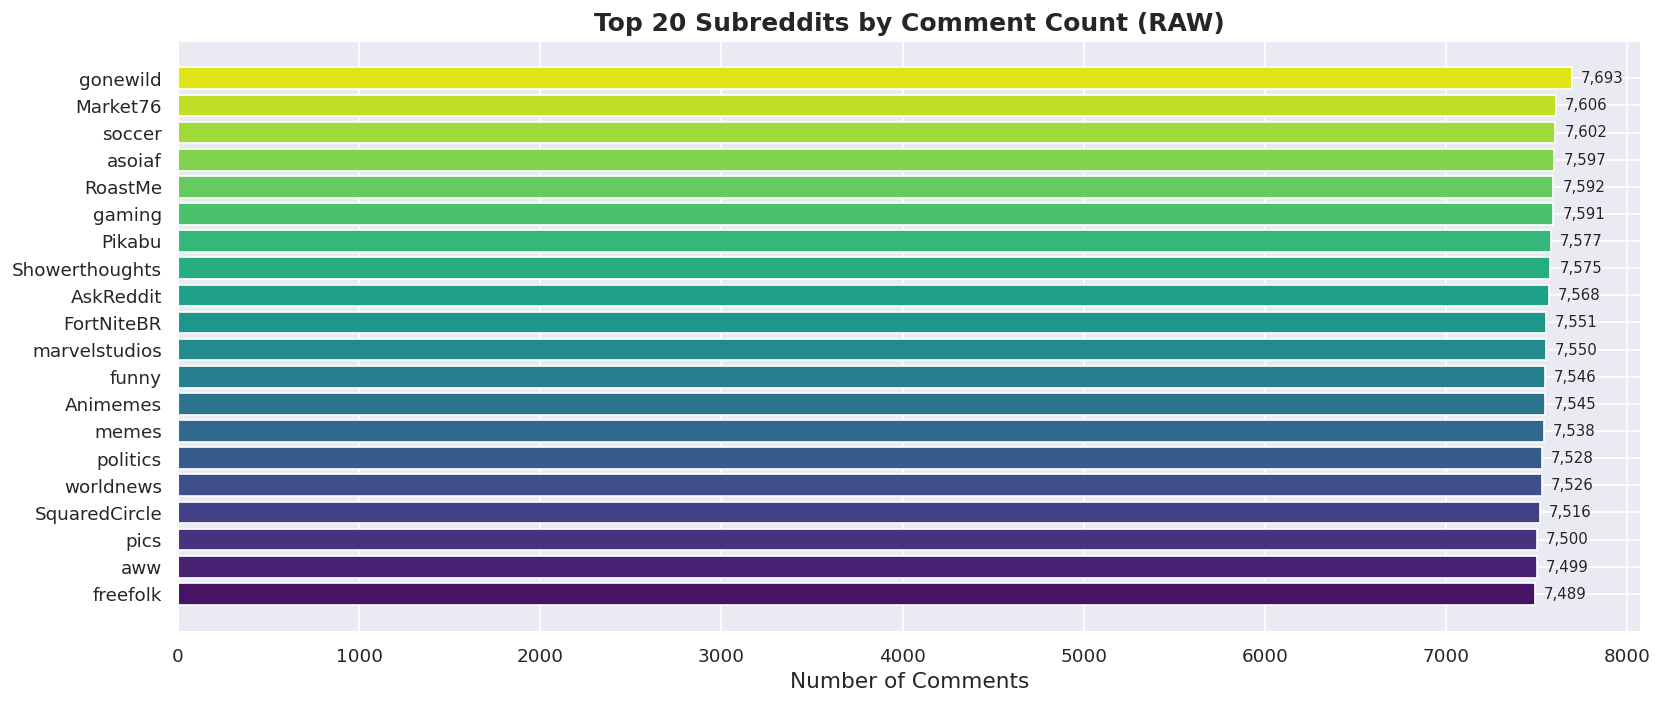

Fig saved!


In [ ]:
# ── 3.1 Posts per Subreddit (Top 20) ──
if 'subreddit' in df.columns:
    top_subs = df['subreddit'].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.barh(top_subs.index[::-1], top_subs.values[::-1],
                   color=sns.color_palette('viridis', 20))
    ax.set_xlabel('Number of Comments', fontsize=13)
    ax.set_title('Top 20 Subreddits by Comment Count (RAW)', fontsize=15, fontweight='bold')
    for bar, val in zip(bars, top_subs.values[::-1]):
        ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/DVA_viz_raw_subreddit_bar.png', dpi=150)
    plt.show()
    print('Fig saved!')

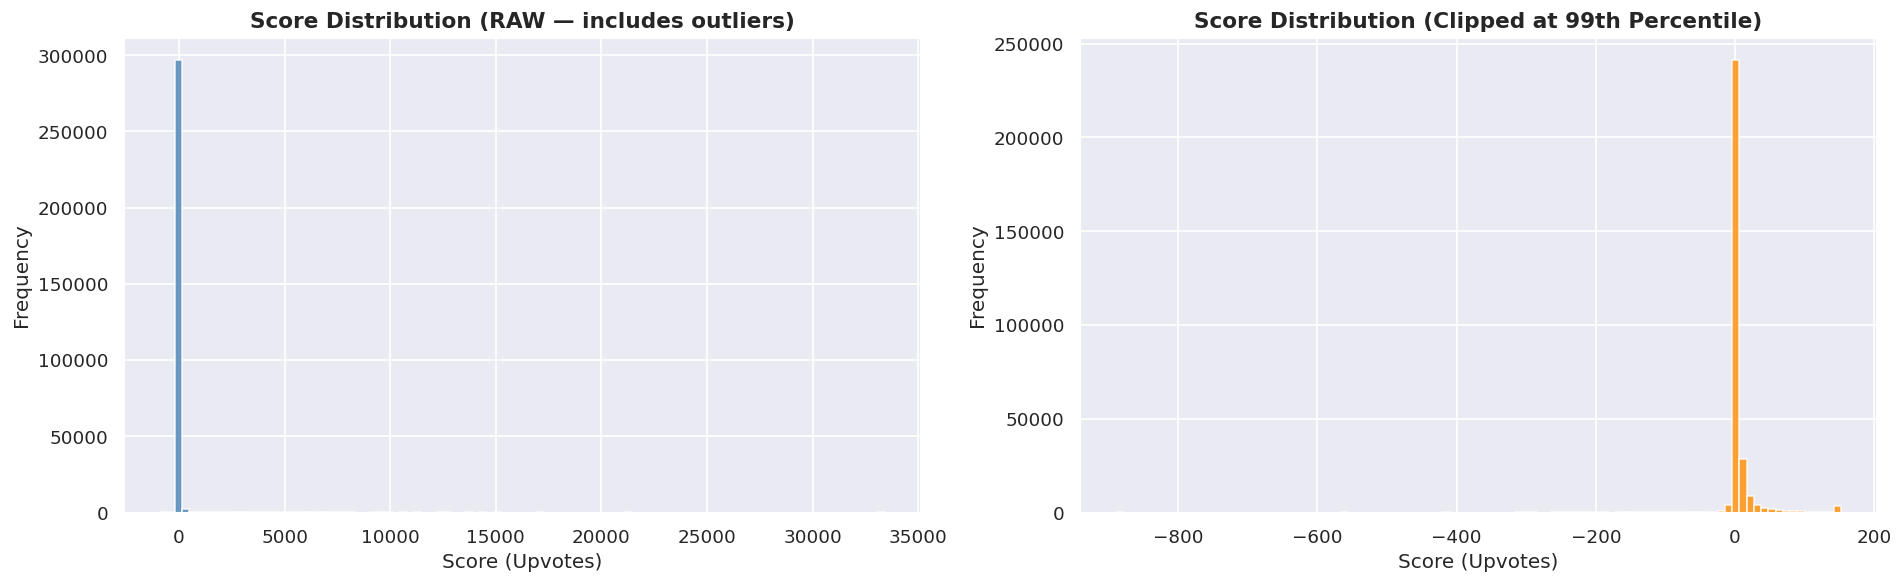

In [ ]:
# ── 3.2 Score (Likes/Upvotes) Distribution ──
if 'score' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Raw distribution
    scores = df['score'].dropna()
    axes[0].hist(scores, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].set_title('Score Distribution (RAW — includes outliers)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Score (Upvotes)')
    axes[0].set_ylabel('Frequency')

    # Clipped for readability
    axes[1].hist(scores.clip(upper=scores.quantile(0.99)), bins=100,
                 color='darkorange', edgecolor='white', alpha=0.8)
    axes[1].set_title('Score Distribution (Clipped at 99th Percentile)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Score (Upvotes)')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/DVA_viz_raw_score_dist.png', dpi=150)
    plt.show()

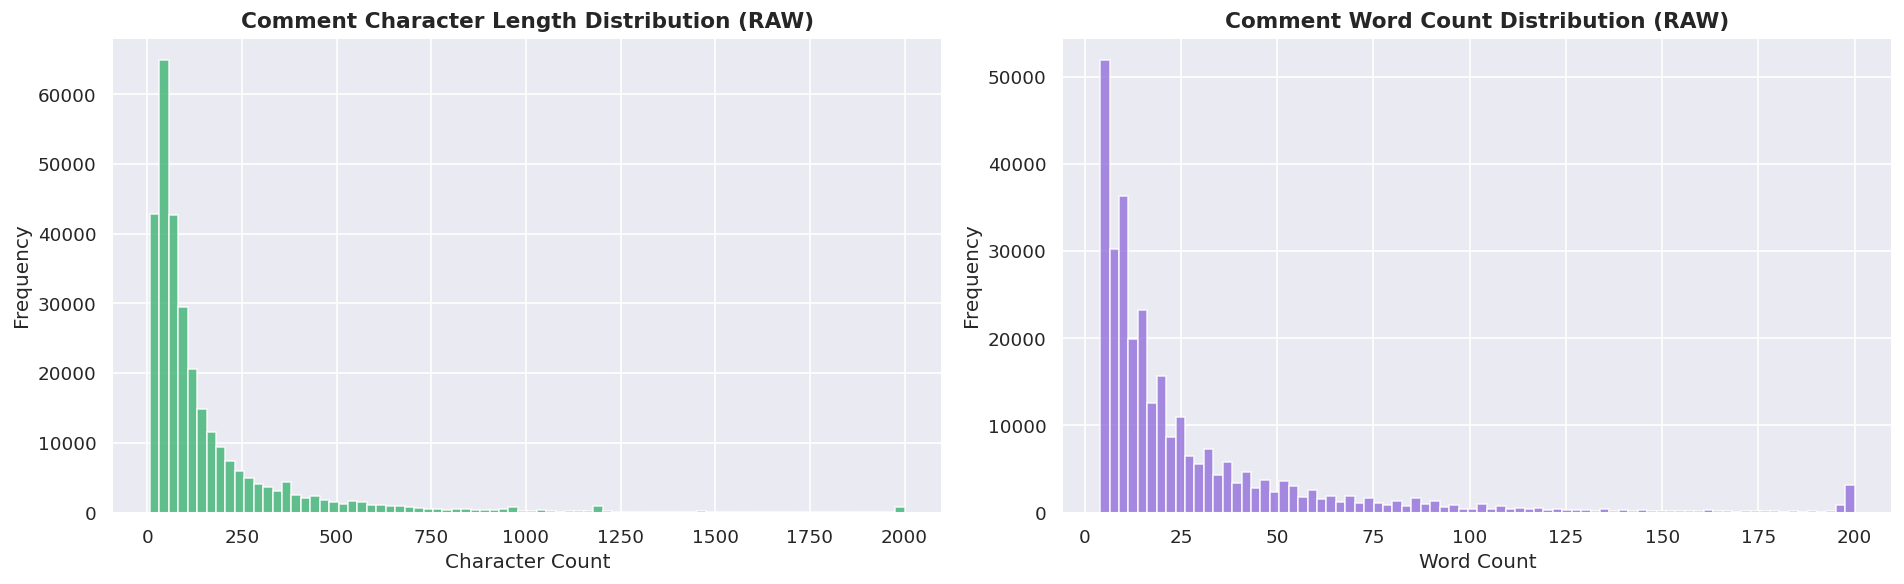

Avg character length : 166.5
Avg word count       : 29.0


In [ ]:
# ── 3.3 Comment Length Distribution (RAW) ──
df['raw_comment_length'] = df['comment_text'].astype(str).apply(len)
df['raw_word_count'] = df['comment_text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['raw_comment_length'].clip(upper=2000), bins=80,
             color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[0].set_title('Comment Character Length Distribution (RAW)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['raw_word_count'].clip(upper=200), bins=80,
             color='mediumpurple', edgecolor='white', alpha=0.8)
axes[1].set_title('Comment Word Count Distribution (RAW)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DVA_viz_raw_length_dist.png', dpi=150)
plt.show()
print(f'Avg character length : {df["raw_comment_length"].mean():.1f}')
print(f'Avg word count       : {df["raw_word_count"].mean():.1f}')

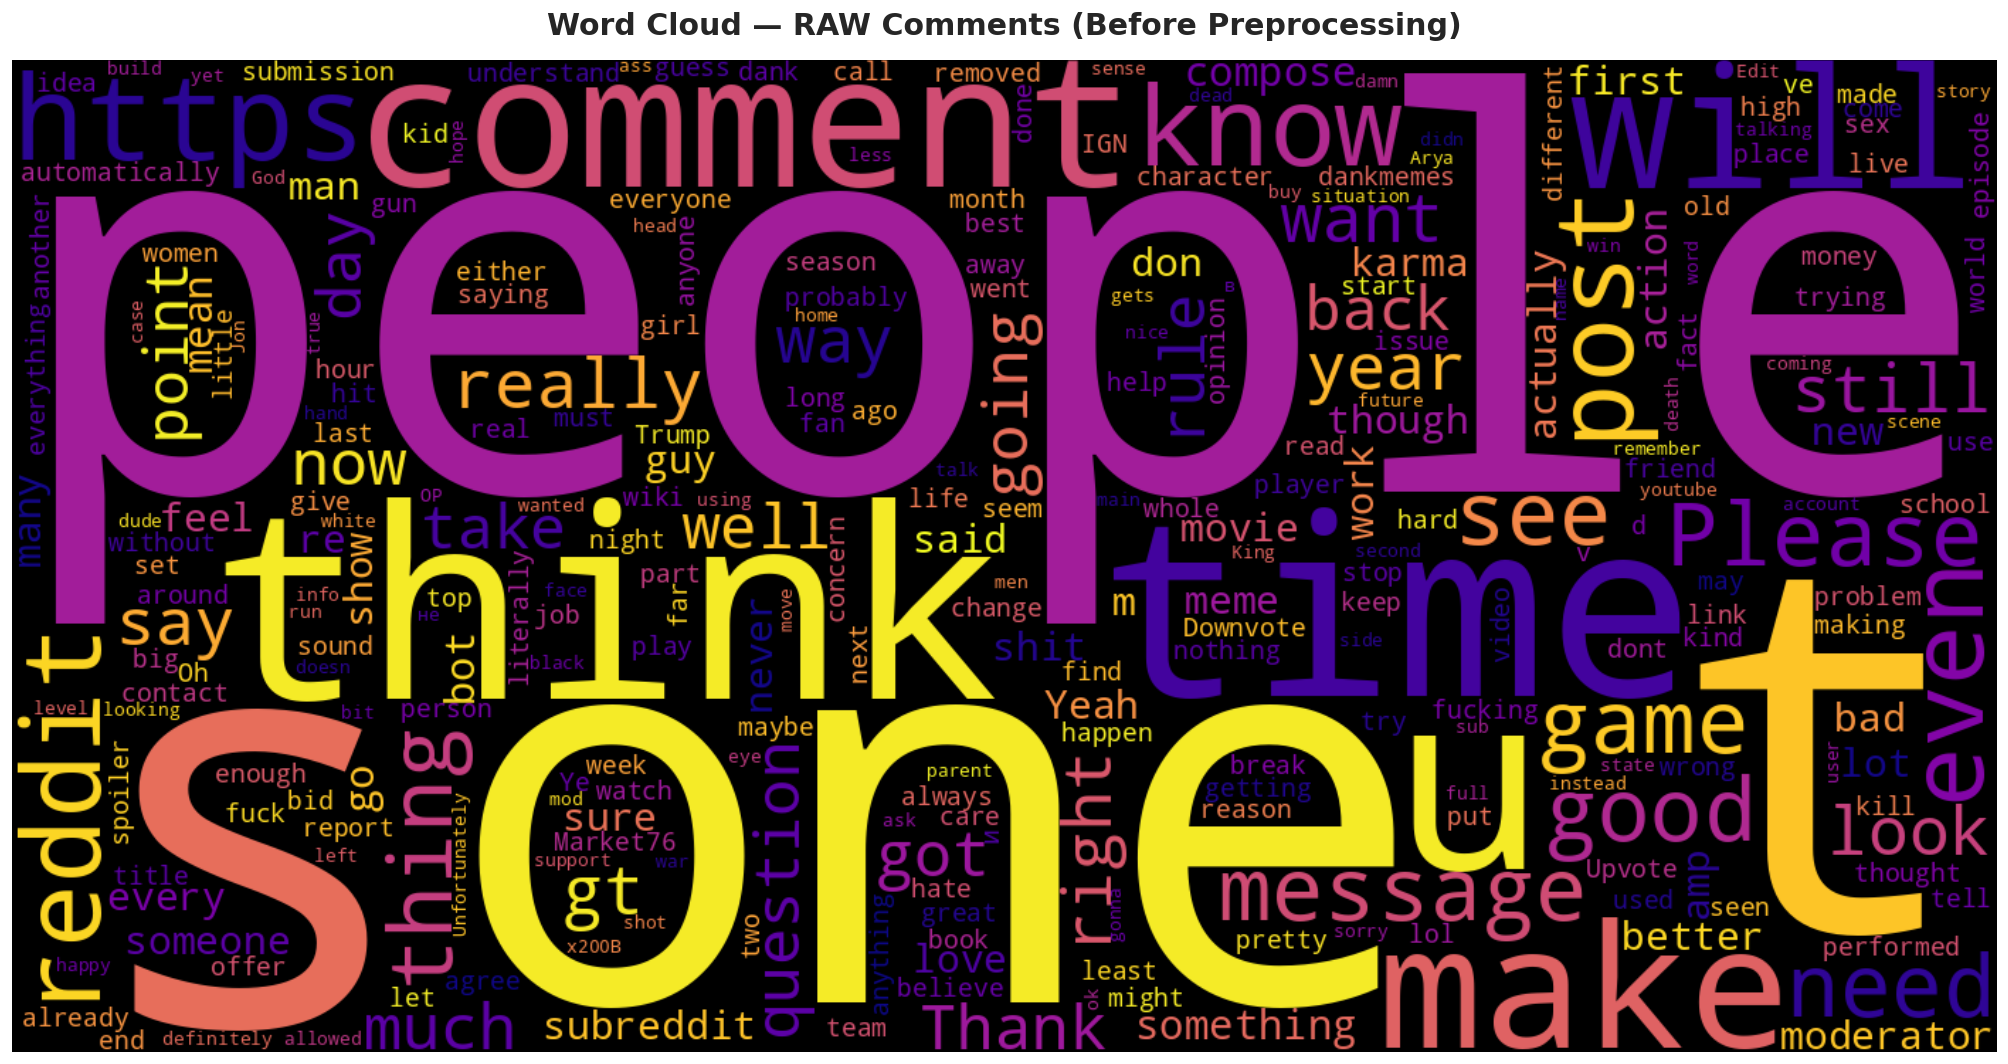

In [ ]:
# ── 3.4 Word Cloud — RAW Comments ──
raw_text = ' '.join(df['comment_text'].astype(str).sample(10000, random_state=1).tolist())

wc = WordCloud(
    width=1400, height=700,
    background_color='black',
    colormap='plasma',
    max_words=300,
    collocations=False
).generate(raw_text)

plt.figure(figsize=(18, 9))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — RAW Comments (Before Preprocessing)', fontsize=18, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DVA_viz_raw_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

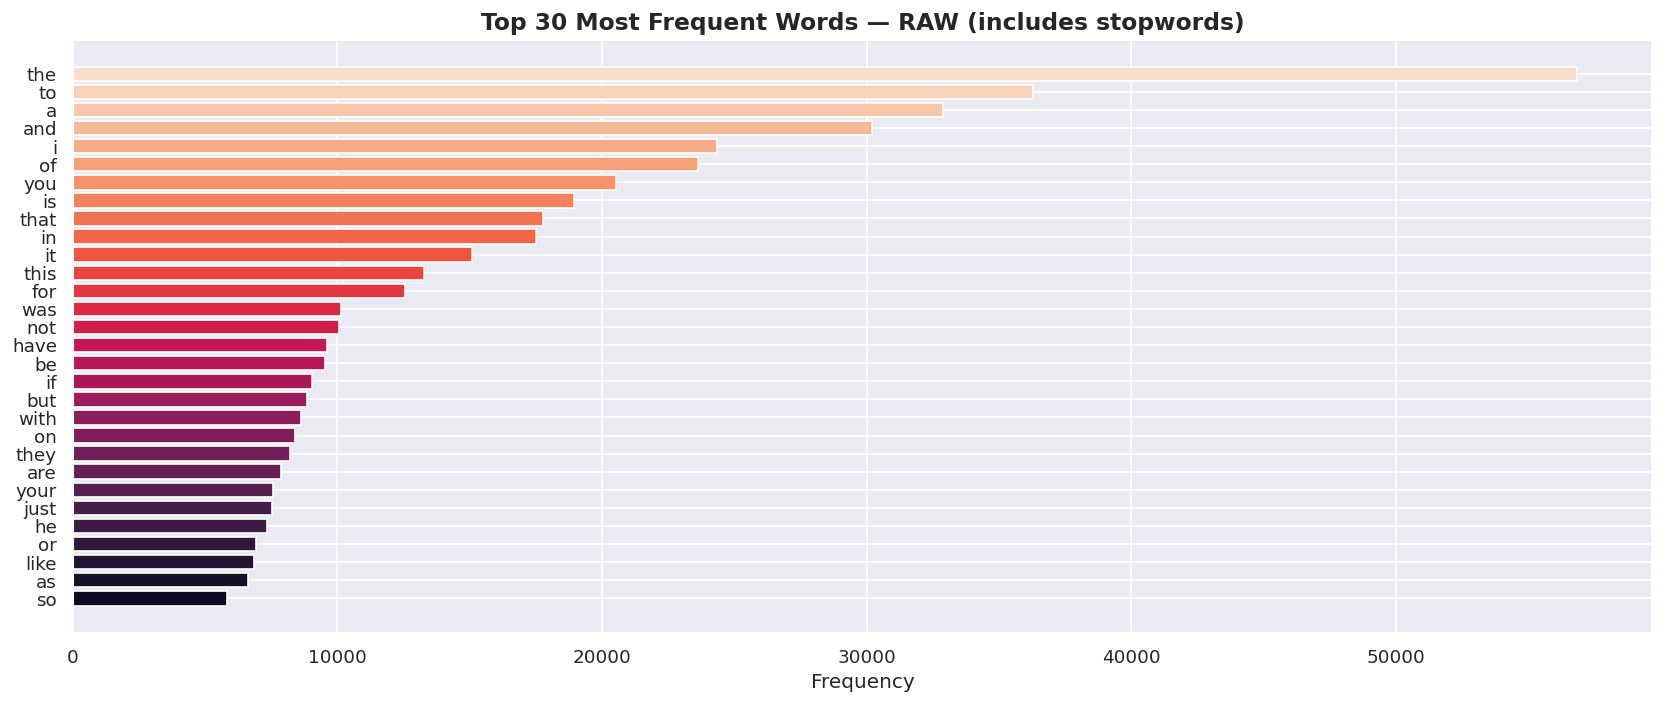

In [ ]:
# ── 3.5 Top 30 Most Frequent Words (RAW) ──
from collections import Counter

raw_words = ' '.join(df['comment_text'].astype(str).sample(50000, random_state=1)).lower().split()
word_freq = Counter(raw_words).most_common(30)
words, freqs = zip(*word_freq)

fig, ax = plt.subplots(figsize=(14, 6))
colors = sns.color_palette('rocket', 30)
ax.barh(list(words)[::-1], list(freqs)[::-1], color=colors)
ax.set_title('Top 30 Most Frequent Words — RAW (includes stopwords)', fontsize=14, fontweight='bold')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DVA_viz_raw_top_words.png', dpi=150)
plt.show()

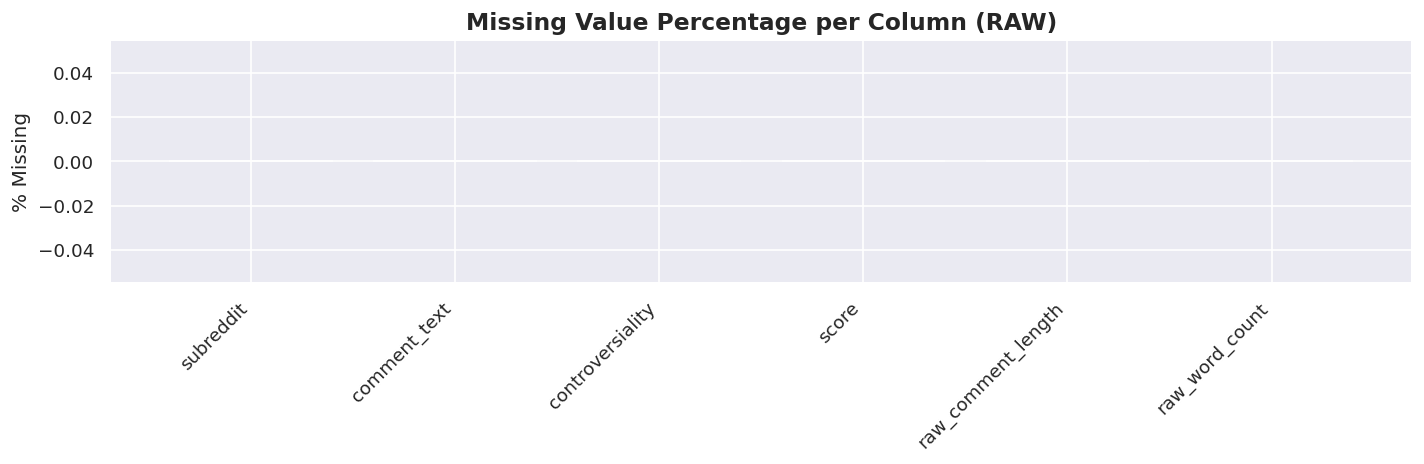

In [ ]:
# ── 3.6 Null Value Heatmap ──
fig, ax = plt.subplots(figsize=(12, 4))
null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
bars = ax.bar(null_pct.index, null_pct.values, color=['crimson' if v > 0 else 'steelblue' for v in null_pct.values])
ax.set_title('Missing Value Percentage per Column (RAW)', fontsize=14, fontweight='bold')
ax.set_ylabel('% Missing')
ax.set_xticklabels(null_pct.index, rotation=45, ha='right')
for bar, val in zip(bars, null_pct.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DVA_viz_raw_nulls.png', dpi=150)
plt.show()

In [ ]:
# ── 3.7 Time Series — Comments Over Time (RAW) ──
if 'timestamp' in df.columns:
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='s', errors='coerce')
    df['year_month'] = df['datetime'].dt.to_period('M')

    ts = df.groupby('year_month').size().reset_index(name='count')
    ts['year_month_str'] = ts['year_month'].astype(str)

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(ts['year_month_str'], ts['count'], marker='o', markersize=3,
            color='dodgerblue', linewidth=1.5)
    ax.fill_between(ts['year_month_str'], ts['count'], alpha=0.2, color='dodgerblue')
    ax.set_title('Comment Volume Over Time (RAW)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of Comments')
    tick_step = max(1, len(ts) // 12)
    ax.set_xticks(ts['year_month_str'][::tick_step])
    ax.set_xticklabels(ts['year_month_str'][::tick_step], rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/DVA_viz_raw_timeseries.png', dpi=150)
    plt.show()
else:
    print('No timestamp column found — skipping time series.')

No timestamp column found — skipping time series.


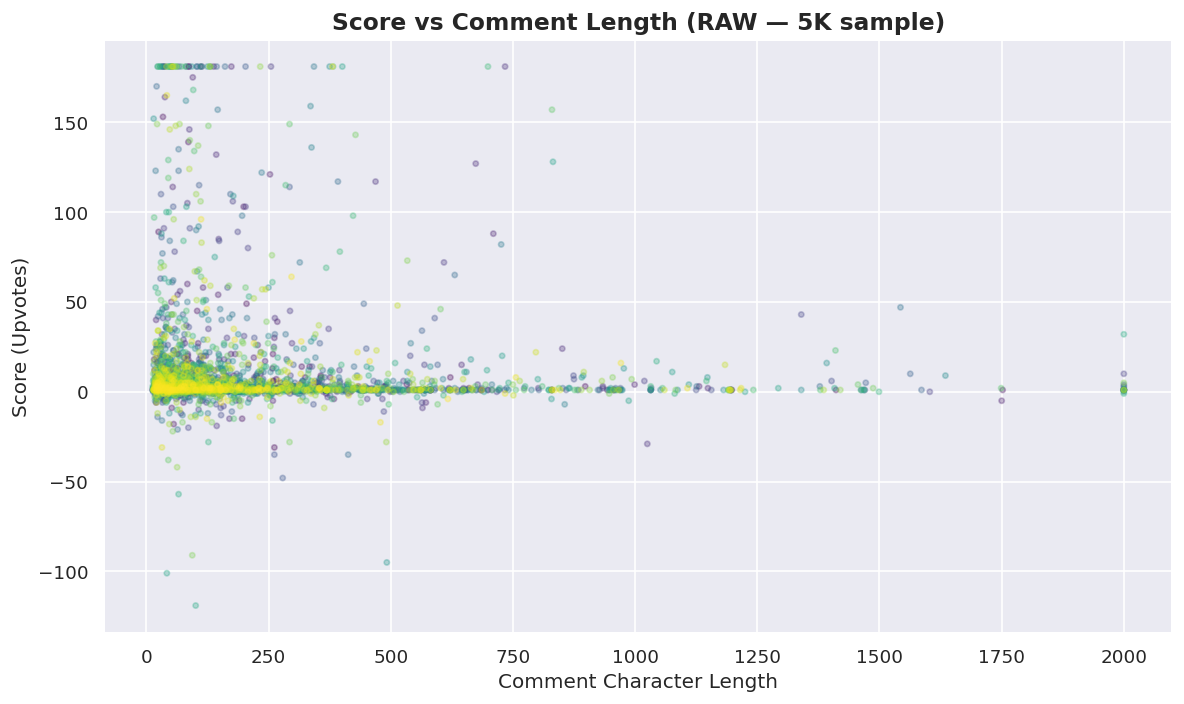

In [ ]:
# ── 3.8 Score vs Comment Length Scatter (RAW) ──
if 'score' in df.columns:
    sample = df[['score', 'raw_comment_length', 'subreddit']].dropna().sample(5000, random_state=42)
    fig, ax = plt.subplots(figsize=(10, 6))
    scatter = ax.scatter(
        sample['raw_comment_length'].clip(upper=2000),
        sample['score'].clip(upper=sample['score'].quantile(0.99)),
        alpha=0.3, s=10, c=range(len(sample)), cmap='viridis'
    )
    ax.set_title('Score vs Comment Length (RAW — 5K sample)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Comment Character Length')
    ax.set_ylabel('Score (Upvotes)')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/DVA_viz_raw_scatter.png', dpi=150)
    plt.show()

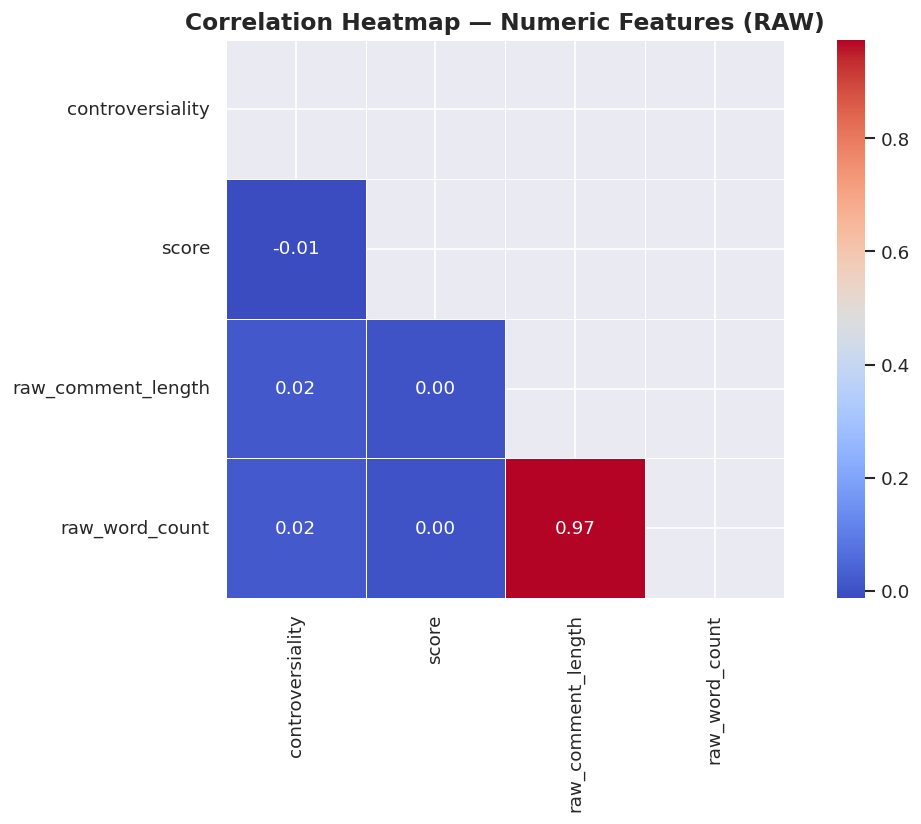

In [ ]:
# ── 3.9 Correlation Heatmap (Numeric Columns — RAW) ──
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) >= 2:
    fig, ax = plt.subplots(figsize=(10, 7))
    corr = df[numeric_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                mask=mask, ax=ax, linewidths=0.5, square=True)
    ax.set_title('Correlation Heatmap — Numeric Features (RAW)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/DVA_viz_raw_corr.png', dpi=150)
    plt.show()

In [ ]:
# ── 3.10 Author Activity Distribution (RAW) ──
if 'author' in df.columns:
    author_counts = df['author'].value_counts()
    activity_bins = pd.cut(author_counts, bins=[0,1,5,10,50,100,np.inf],
                           labels=['1 comment','2-5','6-10','11-50','51-100','100+'])
    activity_dist = activity_bins.value_counts().sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    activity_dist.plot(kind='bar', ax=axes[0], color=sns.color_palette('magma', len(activity_dist)), edgecolor='white')
    axes[0].set_title('Author Activity Distribution (RAW)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Comment Count Bucket')
    axes[0].set_ylabel('Number of Authors')
    axes[0].tick_params(axis='x', rotation=30)

    top_authors = author_counts.head(20)
    axes[1].barh(top_authors.index[::-1], top_authors.values[::-1], color=sns.color_palette('magma', 20))
    axes[1].set_title('Top 20 Most Active Authors (RAW)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Number of Comments')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/DVA_viz_raw_authors.png', dpi=150)
    plt.show()

## 🧹 SECTION 4 — Preprocessing Pipeline

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)

STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print('✅ NLTK resources loaded!')
print(f'Stopwords count: {len(STOPWORDS)}')

✅ NLTK resources loaded!
Stopwords count: 198


In [ ]:
# ── 4.1 Record RAW stats before cleaning ──
stats_before = {
    'total_rows': len(df),
    'null_comments': df['comment_text'].isnull().sum(),
    'duplicate_rows': df.duplicated().sum(),
    'avg_char_length': df['raw_comment_length'].mean(),
    'avg_word_count': df['raw_word_count'].mean(),
    'empty_or_deleted': df['comment_text'].astype(str).str.strip().isin(['', '[deleted]', '[removed]']).sum()
}
print('📊 Stats BEFORE preprocessing:')
for k, v in stats_before.items():
    print(f'  {k:25s}: {v:,.0f}')

📊 Stats BEFORE preprocessing:
  total_rows               : 300,000
  null_comments            : 0
  duplicate_rows           : 5,749
  avg_char_length          : 167
  avg_word_count           : 29
  empty_or_deleted         : 0


In [ ]:
# ── 4.2 Full Preprocessing Function ──
def preprocess_text(text):
    if not isinstance(text, str):
        return ''
    # Remove deleted/removed placeholders
    if text.strip().lower() in ['[deleted]', '[removed]', 'nan', '']:
        return ''
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove Reddit-specific markdown (>quote, *bold*, etc.)
    text = re.sub(r'[*_~`>#|\[\]()]', ' ', text)
    # Remove emojis and non-ASCII
    text = text.encode('ascii', 'ignore').decode('ascii')
    # Remove special characters, keep letters and spaces
    text = re.sub(r"[^a-z\s']", ' ', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenize + remove stopwords + lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOPWORDS and len(t) > 2]
    return ' '.join(tokens)

print('✅ Preprocessing function defined!')

✅ Preprocessing function defined!


In [ ]:
# ── 4.3 Apply Preprocessing (with progress bar) ──
from tqdm.auto import tqdm
tqdm.pandas()

print('🔄 Applying preprocessing to 300,000 comments...')
df['clean_text'] = df['comment_text'].astype(str).progress_apply(preprocess_text)

# ── 4.4 Remove rows with empty clean text ──
before_filter = len(df)
df = df[df['clean_text'].str.strip().ne('')].reset_index(drop=True)
after_filter = len(df)
print(f'✅ Preprocessing complete!')
print(f'   Rows removed (empty after cleaning): {before_filter - after_filter:,}')
print(f'   Remaining rows: {after_filter:,}')

🔄 Applying preprocessing to 300,000 comments...


  0%|          | 0/300000 [00:00<?, ?it/s]

✅ Preprocessing complete!
   Rows removed (empty after cleaning): 7,666
   Remaining rows: 292,334


In [ ]:
# ── 4.5 Post-preprocessing stats ──
df['clean_char_length'] = df['clean_text'].apply(len)
df['clean_word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

# Remove duplicates
before_dedup = len(df)
df.drop_duplicates(subset='clean_text', inplace=True)
df.reset_index(drop=True, inplace=True)

stats_after = {
    'total_rows': len(df),
    'null_comments': df['clean_text'].isnull().sum(),
    'duplicate_rows': df.duplicated().sum(),
    'avg_char_length': df['clean_char_length'].mean(),
    'avg_word_count': df['clean_word_count'].mean(),
    'duplicates_removed': before_dedup - len(df)
}
print('📊 Stats AFTER preprocessing:')
for k, v in stats_after.items():
    print(f'  {k:25s}: {v:,.0f}')

📊 Stats AFTER preprocessing:
  total_rows               : 279,221
  null_comments            : 0
  duplicate_rows           : 0
  avg_char_length          : 94
  avg_word_count           : 14
  duplicates_removed       : 13,113


In [ ]:
# ── 4.6 Save preprocessed dataset to Drive ──
df.to_csv('/content/drive/MyDrive/reddit_preprocessed_300k.csv', index=False)
print('✅ Preprocessed dataset saved to Google Drive!')
print(df[['comment_text', 'clean_text']].head(5))

✅ Preprocessed dataset saved to Google Drive!
                                        comment_text  \
0  How ironic that you're being indignant on the ...   
1  I started work in 99 when the boomers we're st...   
2  Any combination of the following:\n\nAAE Pump ...   
3  Compare pharma's marketing budget to it's R&am...   
4                Wasn't it an illegitimate election?   

                                          clean_text  
0  ironic indignant topic know anything papa john...  
1  started work boomer still younger full asshole...  
2  combination following aae pump action shotgun ...  
3  compare pharma's marketing budget amp compare ...  
4                              illegitimate election  


## 📊 SECTION 5 — Post-Preprocessing Visualization (Before vs After Comparison)

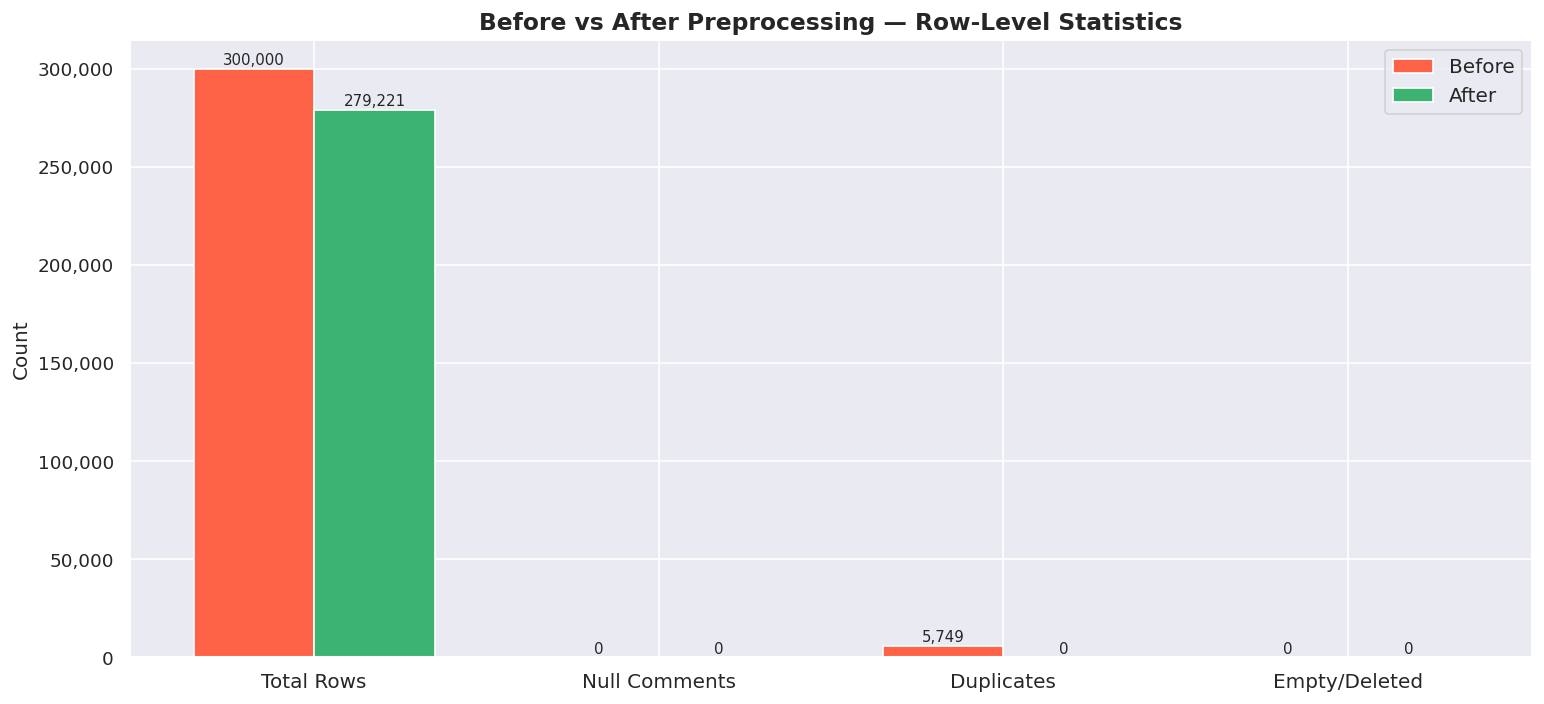

In [ ]:
# ── 5.1 Before vs After — Row Counts ──
labels = ['Total Rows', 'Null Comments', 'Duplicates', 'Empty/Deleted']
before_vals = [stats_before['total_rows'], stats_before['null_comments'],
               stats_before['duplicate_rows'], stats_before['empty_or_deleted']]
after_vals = [stats_after['total_rows'], stats_after['null_comments'],
              stats_after['duplicate_rows'], 0]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - width/2, before_vals, width, label='Before', color='tomato', edgecolor='white')
b2 = ax.bar(x + width/2, after_vals, width, label='After', color='mediumseagreen', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_title('Before vs After Preprocessing — Row-Level Statistics', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.legend(fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in b1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500, f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
for bar in b2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500, f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DVA_viz_compare_rows.png', dpi=150)
plt.show()

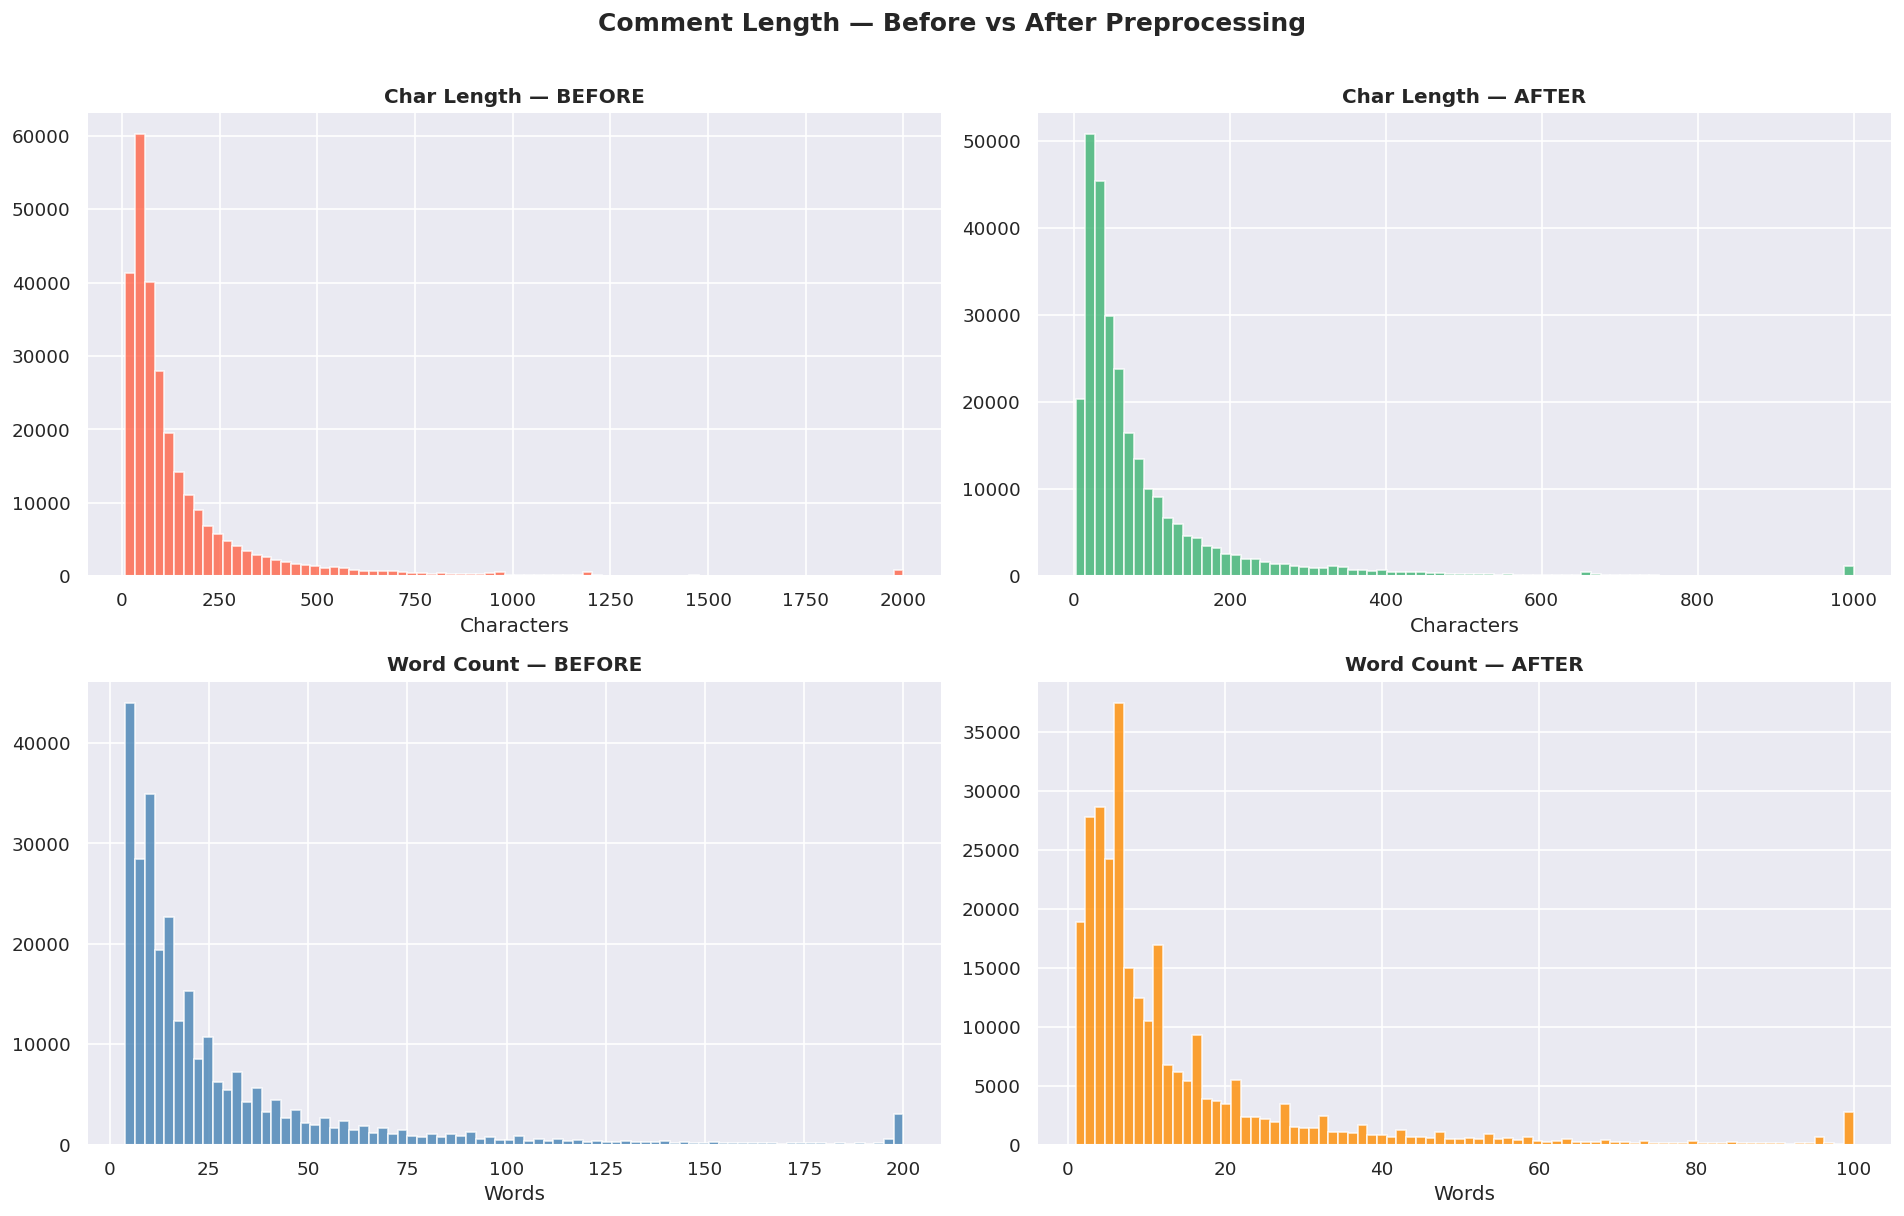

In [ ]:
# ── 5.2 Before vs After — Comment Length Distribution ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].hist(df['raw_comment_length'].clip(upper=2000), bins=80, color='tomato', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Char Length — BEFORE', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Characters')

axes[0,1].hist(df['clean_char_length'].clip(upper=1000), bins=80, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Char Length — AFTER', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Characters')

axes[1,0].hist(df['raw_word_count'].clip(upper=200), bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[1,0].set_title('Word Count — BEFORE', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Words')

axes[1,1].hist(df['clean_word_count'].clip(upper=100), bins=80, color='darkorange', edgecolor='white', alpha=0.8)
axes[1,1].set_title('Word Count — AFTER', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Words')

fig.suptitle('Comment Length — Before vs After Preprocessing', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DVA_viz_compare_length.png', dpi=150, bbox_inches='tight')
plt.show()

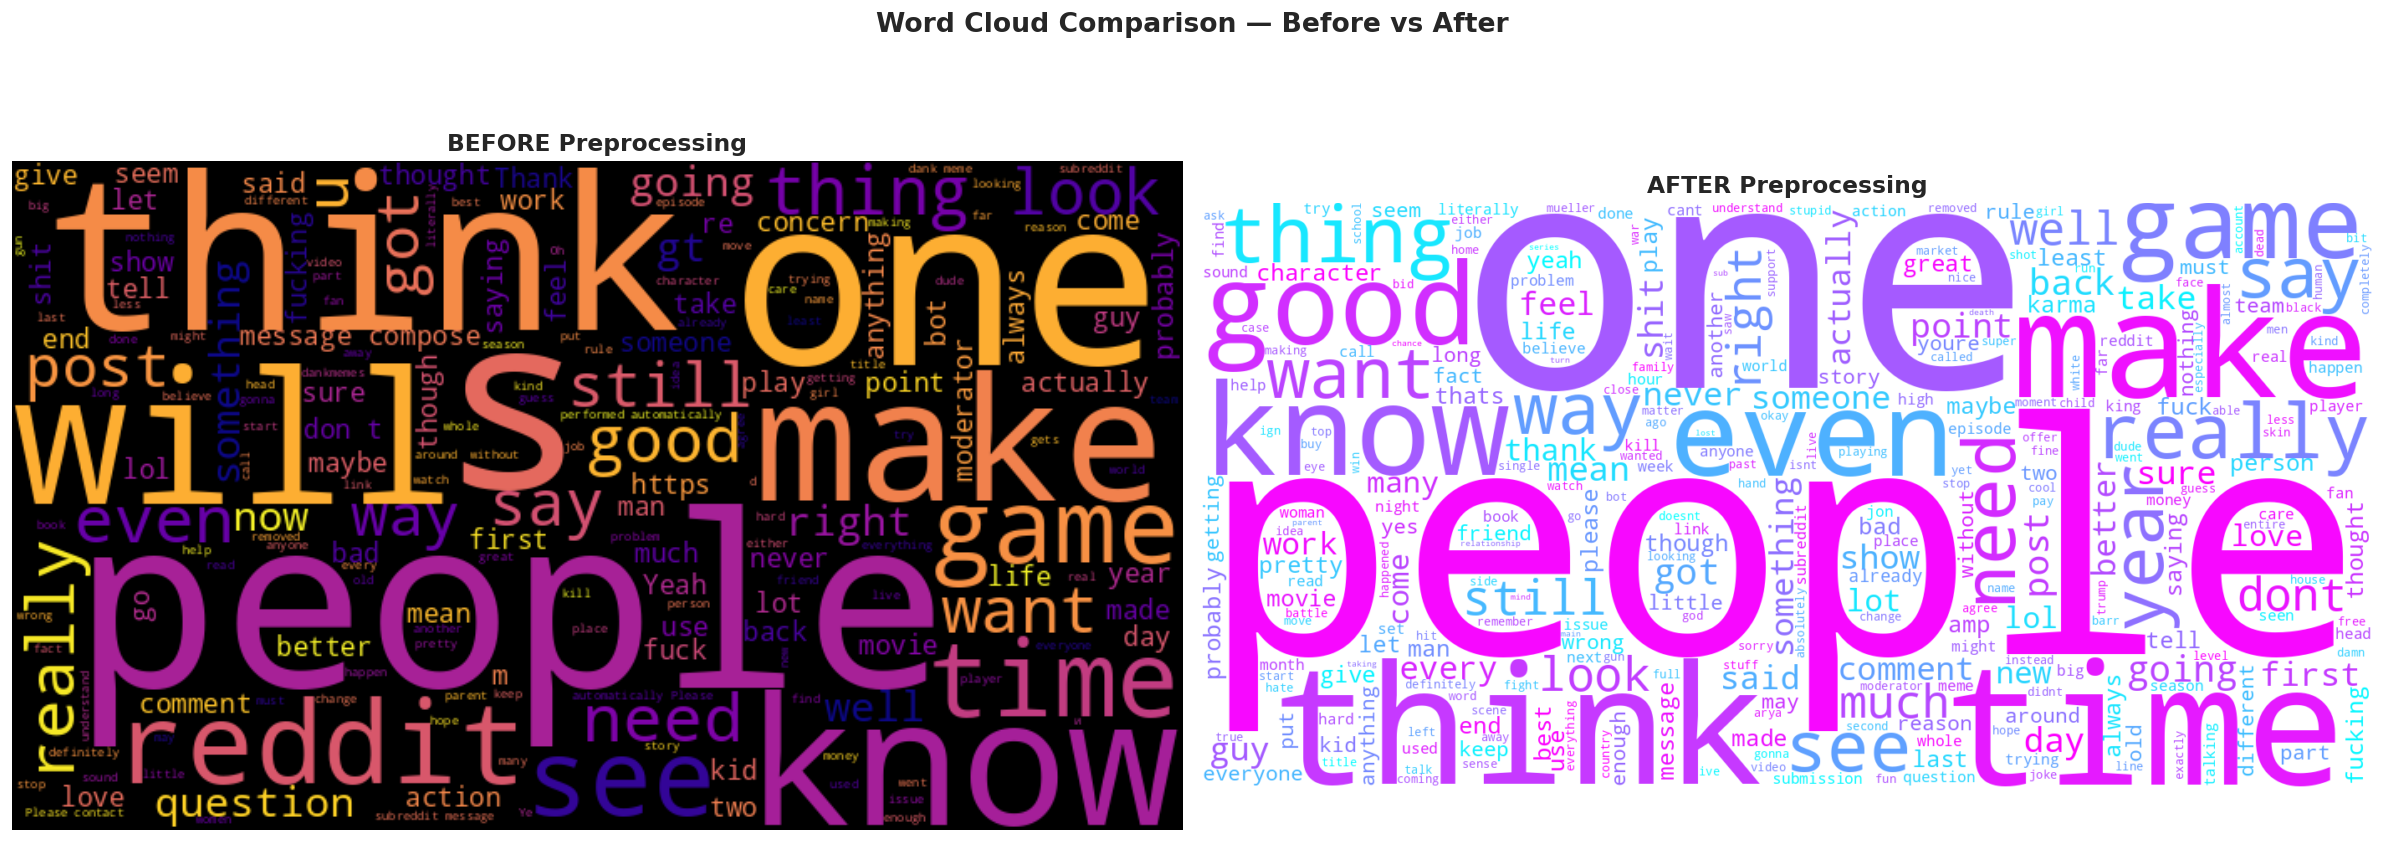

In [ ]:
# ── 5.3 Word Cloud — AFTER Preprocessing ──
clean_text_sample = ' '.join(df['clean_text'].sample(10000, random_state=1).tolist())

wc_clean = WordCloud(
    width=1400, height=700,
    background_color='white',
    colormap='cool',
    max_words=300,
    collocations=False
).generate(clean_text_sample)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
wc_raw = WordCloud(width=700, height=400, background_color='black', colormap='plasma',
                   max_words=200).generate(raw_text)
axes[0].imshow(wc_raw, interpolation='bilinear'); axes[0].axis('off')
axes[0].set_title('BEFORE Preprocessing', fontsize=14, fontweight='bold')

axes[1].imshow(wc_clean, interpolation='bilinear'); axes[1].axis('off')
axes[1].set_title('AFTER Preprocessing', fontsize=14, fontweight='bold')

fig.suptitle('Word Cloud Comparison — Before vs After', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DVA_viz_compare_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

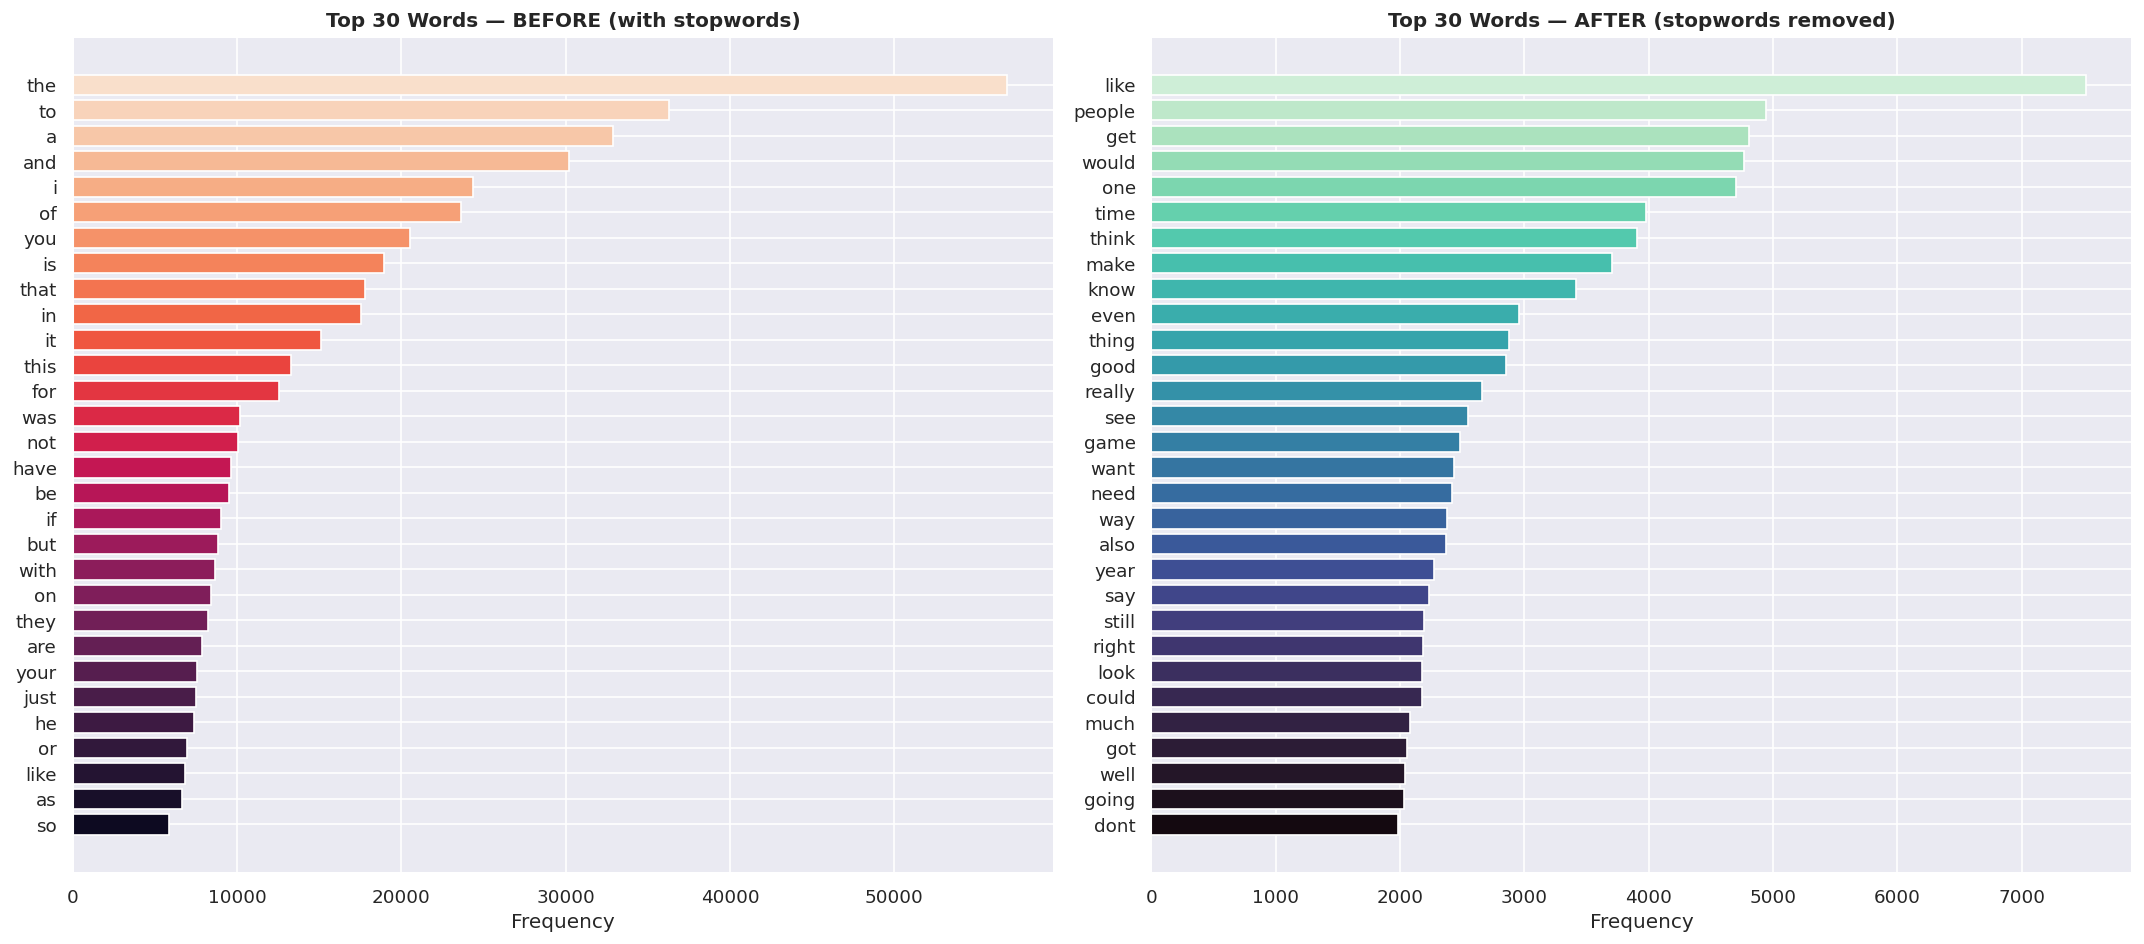

In [ ]:
# ── 5.4 Top 30 Words — Before vs After ──
clean_words = ' '.join(df['clean_text'].sample(50000, random_state=1)).split()
clean_freq = Counter(clean_words).most_common(30)
cw, cf = zip(*clean_freq)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].barh(list(words)[::-1], list(freqs)[::-1], color=sns.color_palette('rocket', 30))
axes[0].set_title('Top 30 Words — BEFORE (with stopwords)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency')

axes[1].barh(list(cw)[::-1], list(cf)[::-1], color=sns.color_palette('mako', 30))
axes[1].set_title('Top 30 Words — AFTER (stopwords removed)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DVA_viz_compare_topwords.png', dpi=150)
plt.show()

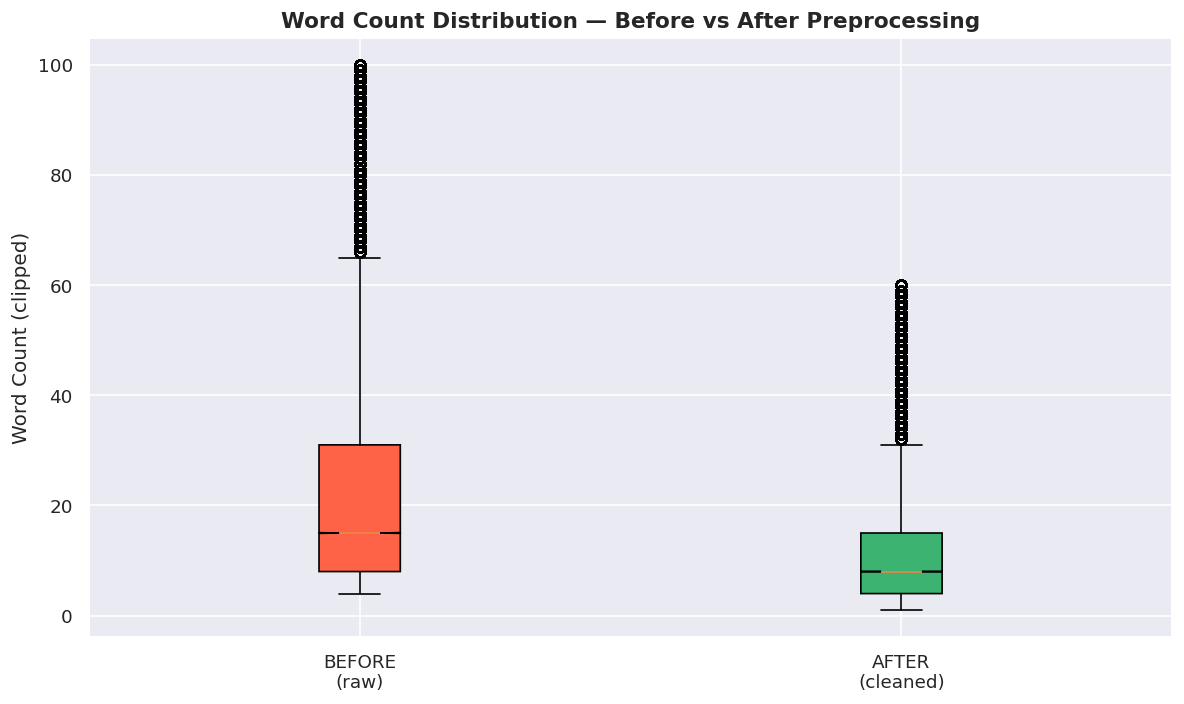

In [ ]:
# ── 5.5 Box Plot — Word Count Before vs After ──
fig, ax = plt.subplots(figsize=(10, 6))
data_to_plot = [
    df['raw_word_count'].clip(upper=100).values,
    df['clean_word_count'].clip(upper=60).values
]
bp = ax.boxplot(data_to_plot, labels=['BEFORE\n(raw)', 'AFTER\n(cleaned)'],
                patch_artist=True, notch=True, vert=True)
bp['boxes'][0].set_facecolor('tomato')
bp['boxes'][1].set_facecolor('mediumseagreen')
ax.set_title('Word Count Distribution — Before vs After Preprocessing', fontsize=13, fontweight='bold')
ax.set_ylabel('Word Count (clipped)')
ax.yaxis.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DVA_viz_compare_boxplot.png', dpi=150)
plt.show()

## 🌍 SECTION 6 — Language Detection & Translation

In [ ]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

def detect_language(text):
    try:
        if len(str(text).strip()) < 10:
            return 'unknown'
        return detect(str(text))
    except:
        return 'unknown'

# Detect languages on sample for speed
print('🔄 Detecting languages (on 50K sample)...')
lang_sample = df['comment_text'].astype(str).sample(50000, random_state=42)
lang_results = lang_sample.progress_apply(detect_language)
df.loc[lang_sample.index, 'language'] = lang_results
print('✅ Language detection done!')

🔄 Detecting languages (on 50K sample)...


  0%|          | 0/50000 [00:00<?, ?it/s]

✅ Language detection done!


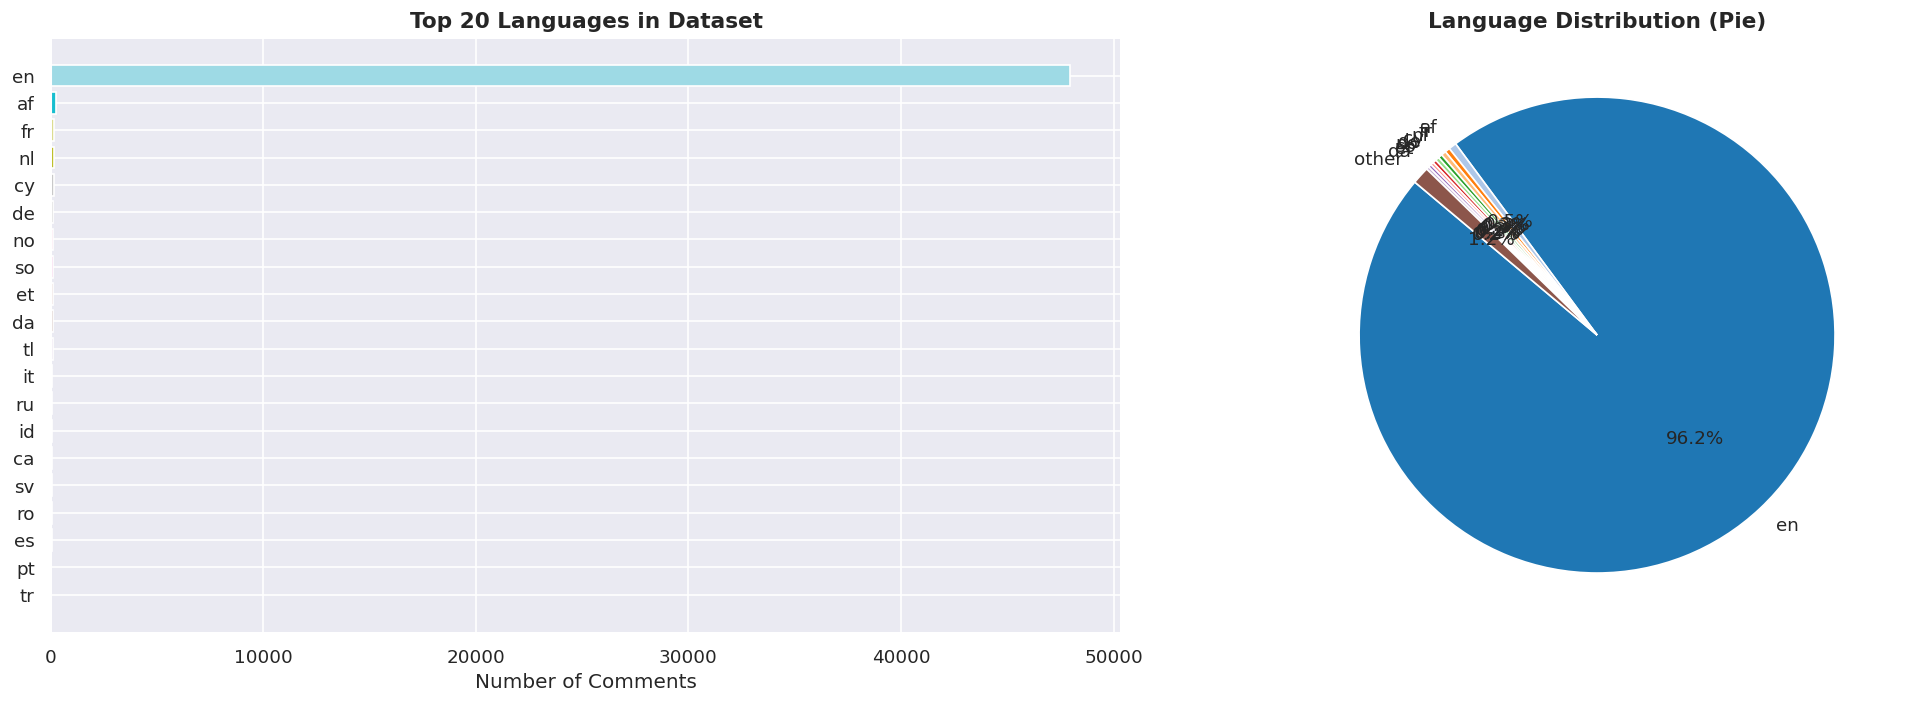

English %: 96.2 %


In [ ]:
# ── 6.1 Language Distribution Visualization ──
lang_counts = df['language'].dropna().value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart
axes[0].barh(lang_counts.index[::-1], lang_counts.values[::-1],
             color=sns.color_palette('tab20', 20))
axes[0].set_title('Top 20 Languages in Dataset', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Comments')

# Pie chart
top10_langs = lang_counts.head(10)
other = lang_counts.iloc[10:].sum()
pie_data = pd.concat([top10_langs, pd.Series({'other': other})])
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('tab20', len(pie_data)))
axes[1].set_title('Language Distribution (Pie)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DVA_viz_language_dist.png', dpi=150)
plt.show()
print('English %:', round(lang_counts.get('en', 0) / lang_counts.sum() * 100, 1), '%')

In [ ]:
# ── 6.2 Translation of Non-English Comments ──
from deep_translator import GoogleTranslator

def translate_to_english(text, src_lang):
    try:
        if src_lang in ['en', 'unknown', None]:
            return text
        if len(str(text).strip()) < 5:
            return text
        return GoogleTranslator(source='auto', target='en').translate(str(text)[:500])
    except:
        return text

# Translate non-English rows (up to 5000 for demo)
non_english_mask = df['language'].notna() & (df['language'] != 'en') & (df['language'] != 'unknown')
non_english_idx = df[non_english_mask].head(5000).index
print(f'Non-English rows (sample for translation): {len(non_english_idx):,}')

print('🔄 Translating...')
df.loc[non_english_idx, 'translated_text'] = df.loc[non_english_idx].progress_apply(
    lambda row: translate_to_english(row['comment_text'], row['language']), axis=1
)
# For English rows, keep original
df['final_text'] = df['translated_text'].fillna(df['clean_text'])
print('✅ Translation complete!')
print(df[['comment_text', 'language', 'translated_text', 'final_text']].dropna(subset=['translated_text']).head(5))

Non-English rows (sample for translation): 2,029
🔄 Translating...


  0%|          | 0/2029 [00:00<?, ?it/s]

✅ Translation complete!
                                          comment_text language  \
44                 Volcel Police please come im scared       ro   
386  чутка поправлю, у меня на оба перманентно заба...       ru   
483                     You’d become Peanut Butter Man       fr   
590                                    I like you boy.       sw   
612                    Dude doesn't wanna go to Turkey       af   

                                       translated_text  \
44                 Volcel Police please come im scared   
386  Let me correct you a bit, I received the follo...   
483                     You’d become Peanut Butter Man   
590                                    I like you boy.   
612                    Dude doesn't wanna go to Turkey   

                                            final_text  
44                 Volcel Police please come im scared  
386  Let me correct you a bit, I received the follo...  
483                     You’d become Peanut Butter Ma

## 🔢 SECTION 7 — Feature Extraction (TF-IDF, Sentiment, Embeddings)

In [ ]:
# ── 7.1 Sentiment Analysis (VADER) ──
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    try:
        scores = analyzer.polarity_scores(str(text))
        compound = scores['compound']
        if compound >= 0.05:
            label = 'positive'
        elif compound <= -0.05:
            label = 'negative'
        else:
            label = 'neutral'
        return compound, scores['pos'], scores['neg'], scores['neu'], label
    except:
        return 0, 0, 0, 1, 'neutral'

print('🔄 Running VADER sentiment analysis...')
sentiment_results = df['clean_text'].progress_apply(get_sentiment)
df['sentiment_compound'] = [r[0] for r in sentiment_results]
df['sentiment_pos']      = [r[1] for r in sentiment_results]
df['sentiment_neg']      = [r[2] for r in sentiment_results]
df['sentiment_neu']      = [r[3] for r in sentiment_results]
df['sentiment_label']    = [r[4] for r in sentiment_results]
print('✅ Sentiment analysis done!')
print(df['sentiment_label'].value_counts())

🔄 Running VADER sentiment analysis...


  0%|          | 0/279221 [00:00<?, ?it/s]

✅ Sentiment analysis done!
sentiment_label
positive    125743
negative     85186
neutral      68292
Name: count, dtype: int64


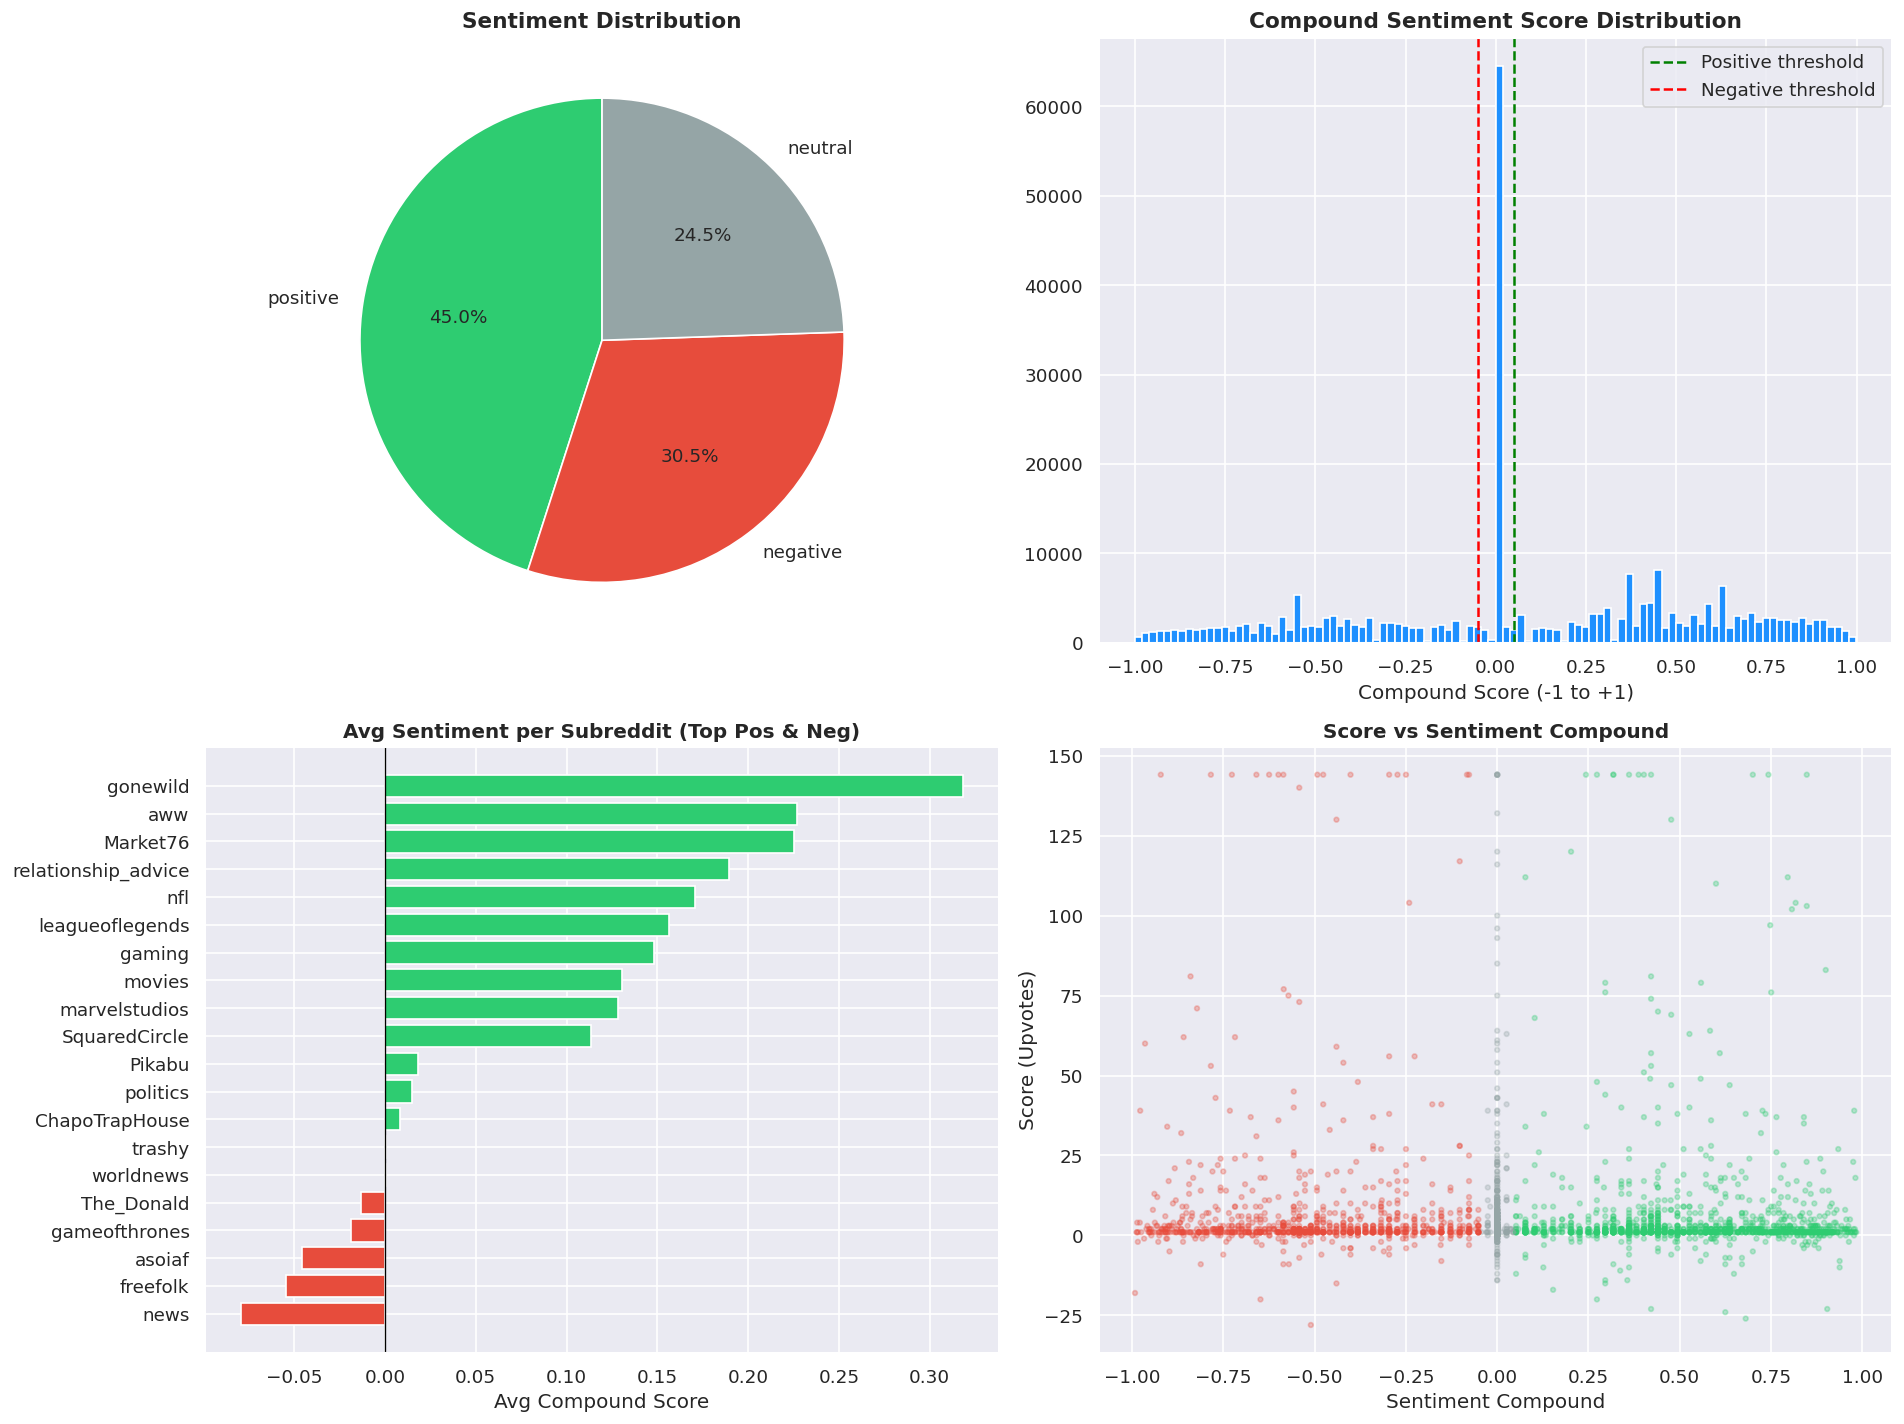

In [ ]:
# ── 7.2 Sentiment Visualizations ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Sentiment label pie
sent_counts = df['sentiment_label'].value_counts()
colors_sent = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}
axes[0,0].pie(sent_counts.values, labels=sent_counts.index, autopct='%1.1f%%',
              colors=[colors_sent[l] for l in sent_counts.index], startangle=90)
axes[0,0].set_title('Sentiment Distribution', fontsize=13, fontweight='bold')

# Compound score distribution
axes[0,1].hist(df['sentiment_compound'], bins=100, color='dodgerblue', edgecolor='white')
axes[0,1].axvline(0.05, color='green', linestyle='--', label='Positive threshold')
axes[0,1].axvline(-0.05, color='red', linestyle='--', label='Negative threshold')
axes[0,1].set_title('Compound Sentiment Score Distribution', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Compound Score (-1 to +1)')
axes[0,1].legend()

# Sentiment per subreddit
if 'subreddit' in df.columns:
    sub_sent = df.groupby('subreddit')['sentiment_compound'].mean().sort_values()
    top_pos = sub_sent.tail(10)
    top_neg = sub_sent.head(10)
    combined = pd.concat([top_neg, top_pos])
    bar_colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in combined.values]
    axes[1,0].barh(combined.index, combined.values, color=bar_colors)
    axes[1,0].axvline(0, color='black', linewidth=0.8)
    axes[1,0].set_title('Avg Sentiment per Subreddit (Top Pos & Neg)', fontsize=12, fontweight='bold')
    axes[1,0].set_xlabel('Avg Compound Score')

# Score vs Sentiment
if 'score' in df.columns:
    sample_s = df[['score', 'sentiment_compound', 'sentiment_label']].dropna().sample(3000, random_state=42)
    scatter_colors = [colors_sent[l] for l in sample_s['sentiment_label']]
    axes[1,1].scatter(sample_s['sentiment_compound'],
                      sample_s['score'].clip(upper=sample_s['score'].quantile(0.99)),
                      c=scatter_colors, alpha=0.3, s=8)
    axes[1,1].set_title('Score vs Sentiment Compound', fontsize=12, fontweight='bold')
    axes[1,1].set_xlabel('Sentiment Compound')
    axes[1,1].set_ylabel('Score (Upvotes)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DVA_viz_sentiment.png', dpi=150)
plt.show()

In [ ]:
# ── 7.3 TF-IDF Feature Extraction ──
from sklearn.feature_extraction.text import TfidfVectorizer

# Use 30k rows for TF-IDF (memory-efficient)
TFIDF_SAMPLE = 30000
df_tfidf = df[df['clean_text'].str.len() > 10].sample(TFIDF_SAMPLE, random_state=42).reset_index(drop=True)

print('🔄 Fitting TF-IDF vectorizer...')
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85
)
X_tfidf = tfidf.fit_transform(df_tfidf['clean_text'])
print(f'✅ TF-IDF matrix shape: {X_tfidf.shape}')
print(f'Top 20 TF-IDF features: {tfidf.get_feature_names_out()[:20].tolist()}')

🔄 Fitting TF-IDF vectorizer...
✅ TF-IDF matrix shape: (30000, 5000)
Top 20 TF-IDF features: ['abandoned', 'ability', 'able', 'able get', 'abortion', 'absolute', 'absolutely', 'absolutely right', 'absurd', 'abuse', 'abused', 'abuser', 'abusive', 'accent', 'accept', 'acceptable', 'accepted', 'accepting', 'access', 'accident']


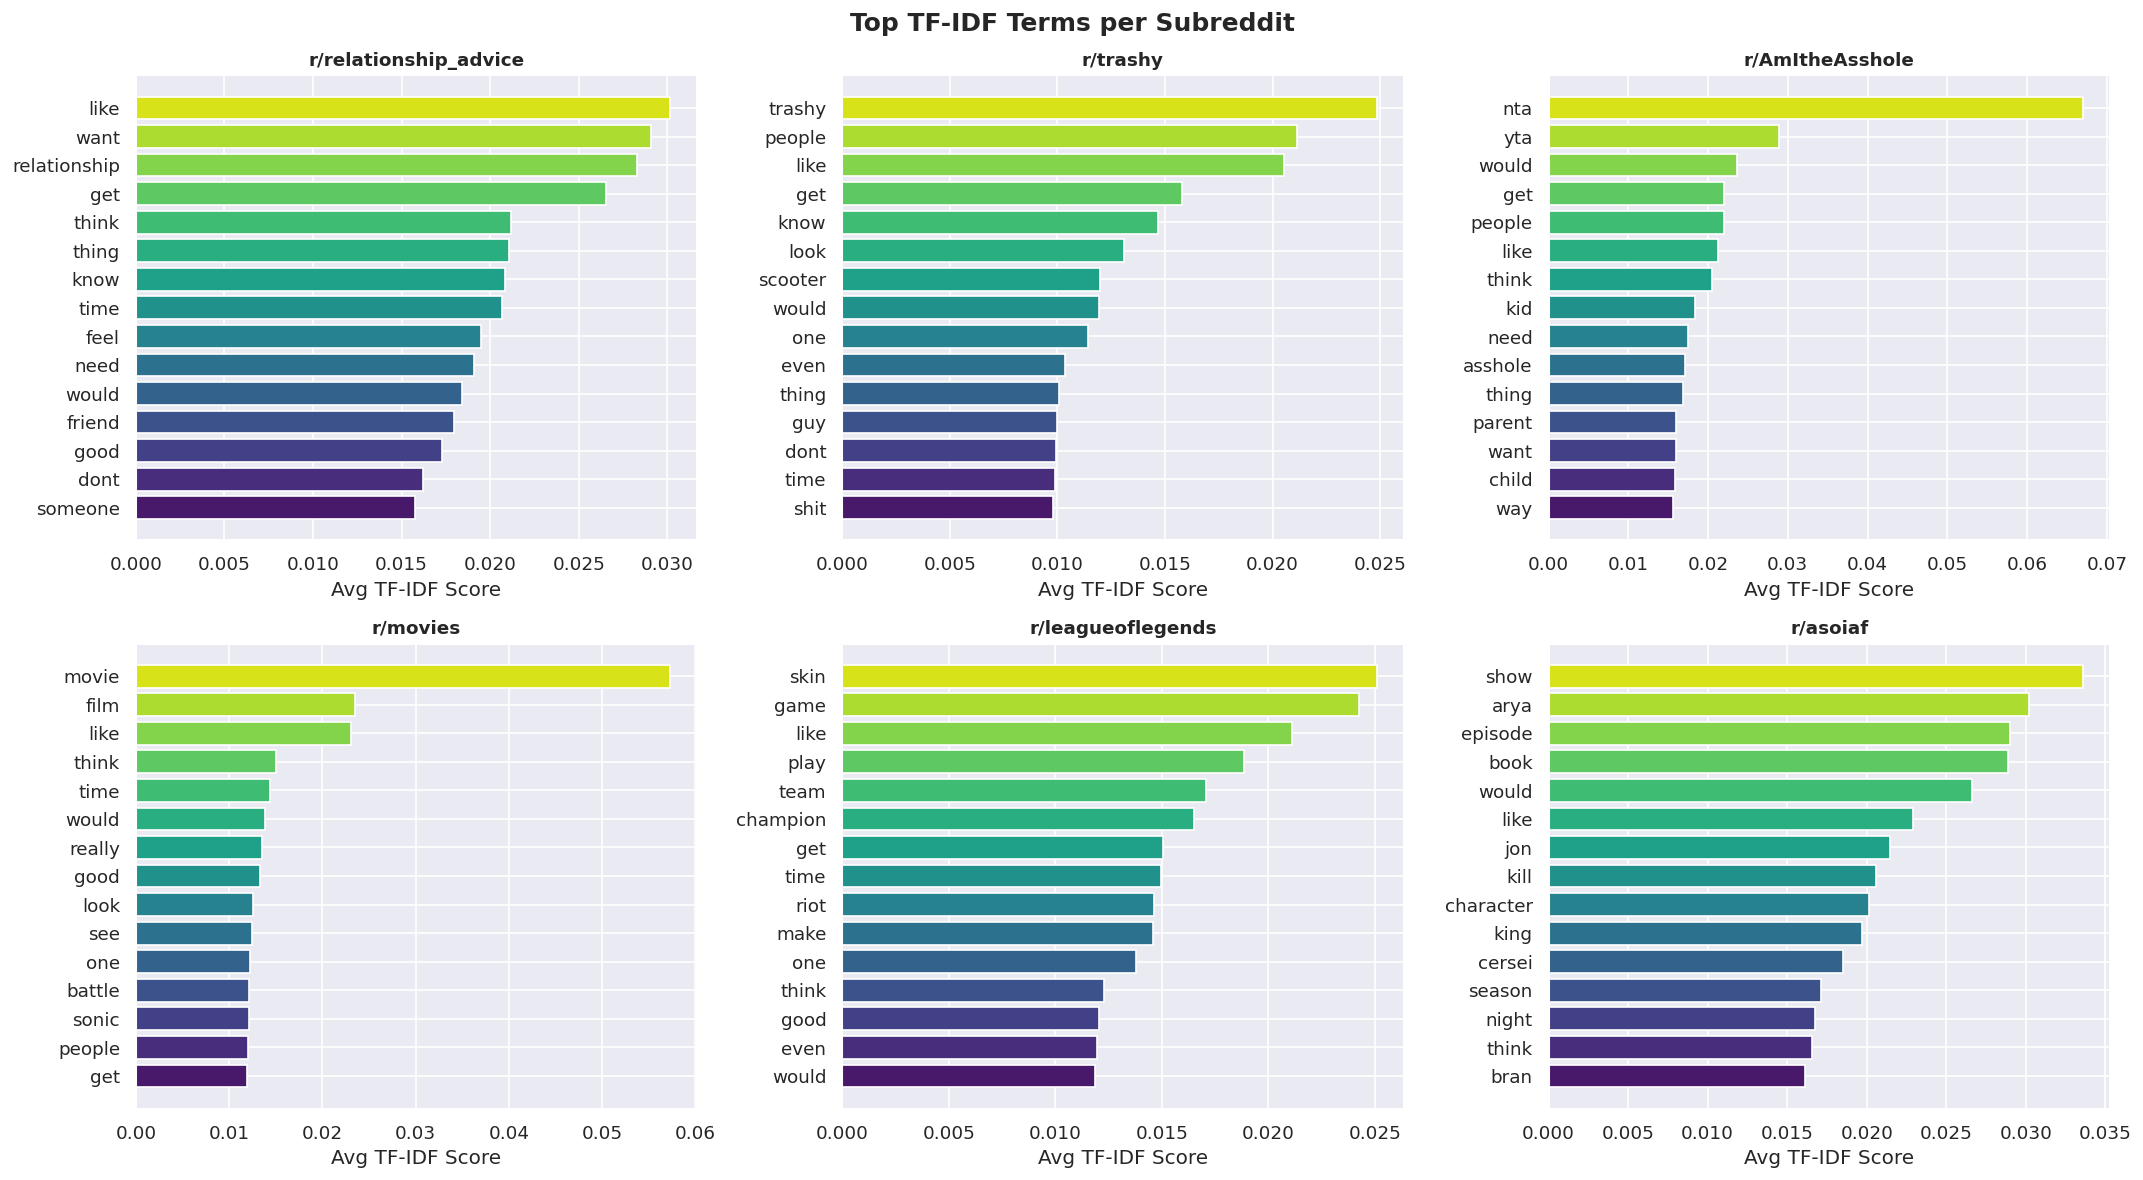

In [ ]:
# ── 7.4 Top TF-IDF Terms per Subreddit ──
if 'subreddit' in df_tfidf.columns:
    feature_names = tfidf.get_feature_names_out()
    top_subreddits = df_tfidf['subreddit'].value_counts().head(6).index.tolist()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, sub in enumerate(top_subreddits):
        sub_mask = df_tfidf['subreddit'] == sub
        if sub_mask.sum() < 5:
            continue
        sub_tfidf = X_tfidf[sub_mask.values].mean(axis=0)
        sub_tfidf_arr = np.asarray(sub_tfidf).flatten()
        top_idx = sub_tfidf_arr.argsort()[-15:][::-1]
        top_terms = [feature_names[i] for i in top_idx]
        top_scores = sub_tfidf_arr[top_idx]

        axes[idx].barh(top_terms[::-1], top_scores[::-1], color=sns.color_palette('viridis', 15))
        axes[idx].set_title(f'r/{sub}', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Avg TF-IDF Score')

    fig.suptitle('Top TF-IDF Terms per Subreddit', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/DVA_viz_tfidf_per_subreddit.png', dpi=150)
    plt.show()

## 🧬 SECTION 8 — Experiment 8: t-SNE (Distributed Stochastic Neighbor Embedding)

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import LabelEncoder
import matplotlib.patches as mpatches

# Use 8000 rows for t-SNE (balance between quality and speed)
TSNE_SAMPLE = 8000
df_tsne = df_tfidf.sample(min(TSNE_SAMPLE, len(df_tfidf)), random_state=42).reset_index(drop=True)
X_sub = tfidf.transform(df_tsne['clean_text'])

print(f't-SNE input shape: {X_sub.shape}')

# Step 1: Reduce to 50 dims with SVD first (recommended before t-SNE)
print('🔄 Step 1: SVD dimensionality reduction (5000 → 50)...')
svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_sub)
print(f'✅ SVD done! Explained variance: {svd.explained_variance_ratio_.sum():.2%}')

t-SNE input shape: (8000, 5000)
🔄 Step 1: SVD dimensionality reduction (5000 → 50)...
✅ SVD done! Explained variance: 11.85%


In [ ]:
# Step 2: t-SNE (50 → 2 dims)
print('🔄 Step 2: t-SNE (50 → 2D)... (this may take 3-5 mins)')
tsne = TSNE(
    n_components=2,
    perplexity=40,
    n_iter=1000,
    learning_rate='auto',
    init='pca',
    random_state=42,
    verbose=1
)
X_tsne = tsne.fit_transform(X_svd)
df_tsne['tsne_x'] = X_tsne[:, 0]
df_tsne['tsne_y'] = X_tsne[:, 1]
print(f'✅ t-SNE done! Output shape: {X_tsne.shape}')

🔄 Step 2: t-SNE (50 → 2D)... (this may take 3-5 mins)
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 8000 samples in 0.001s...
[t-SNE] Computed neighbors for 8000 samples in 0.941s...
[t-SNE] Computed conditional probabilities for sample 1000 / 8000
[t-SNE] Computed conditional probabilities for sample 2000 / 8000
[t-SNE] Computed conditional probabilities for sample 3000 / 8000
[t-SNE] Computed conditional probabilities for sample 4000 / 8000
[t-SNE] Computed conditional probabilities for sample 5000 / 8000
[t-SNE] Computed conditional probabilities for sample 6000 / 8000
[t-SNE] Computed conditional probabilities for sample 7000 / 8000
[t-SNE] Computed conditional probabilities for sample 8000 / 8000
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 87.741302
[t-SNE] KL divergence after 1000 iterations: 1.670275
✅ t-SNE done! Output shape: (8000, 2)


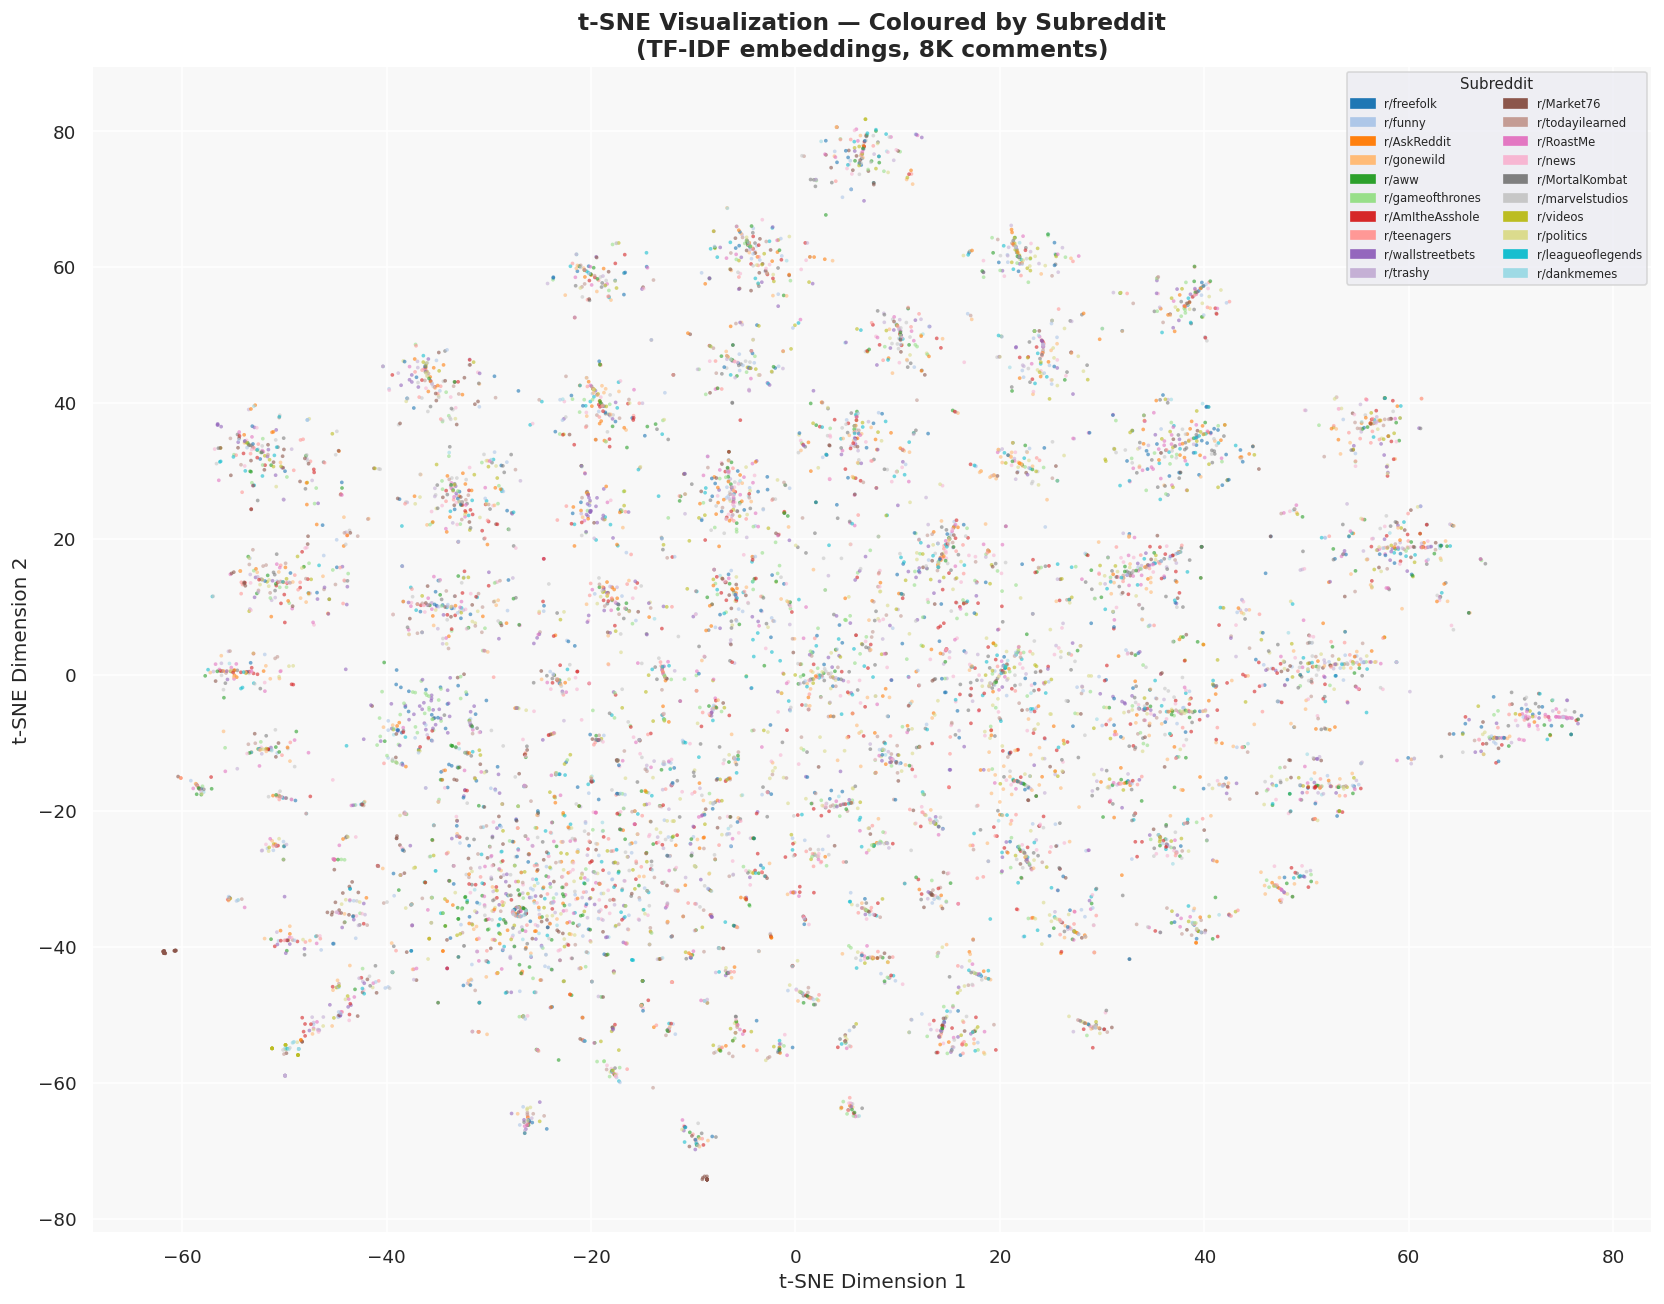

In [ ]:
# ── 8.1 t-SNE coloured by Subreddit ──
if 'subreddit' in df_tsne.columns:
    unique_subs = df_tsne['subreddit'].unique()
    palette = sns.color_palette('tab20', len(unique_subs))
    color_map = dict(zip(unique_subs, palette))
    colors = df_tsne['subreddit'].map(color_map)

    fig, ax = plt.subplots(figsize=(14, 11))
    scatter = ax.scatter(df_tsne['tsne_x'], df_tsne['tsne_y'],
                         c=colors, s=5, alpha=0.6, linewidths=0)
    patches = [mpatches.Patch(color=color_map[s], label=f'r/{s}') for s in list(unique_subs)[:20]]
    ax.legend(handles=patches, loc='upper right', fontsize=7, ncol=2,
              title='Subreddit', title_fontsize=9, framealpha=0.7)
    ax.set_title('t-SNE Visualization — Coloured by Subreddit\n(TF-IDF embeddings, 8K comments)', fontsize=14, fontweight='bold')
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    ax.set_facecolor('#f8f8f8')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/DVA_exp8_tsne_subreddit.png', dpi=150, bbox_inches='tight')
    plt.show()

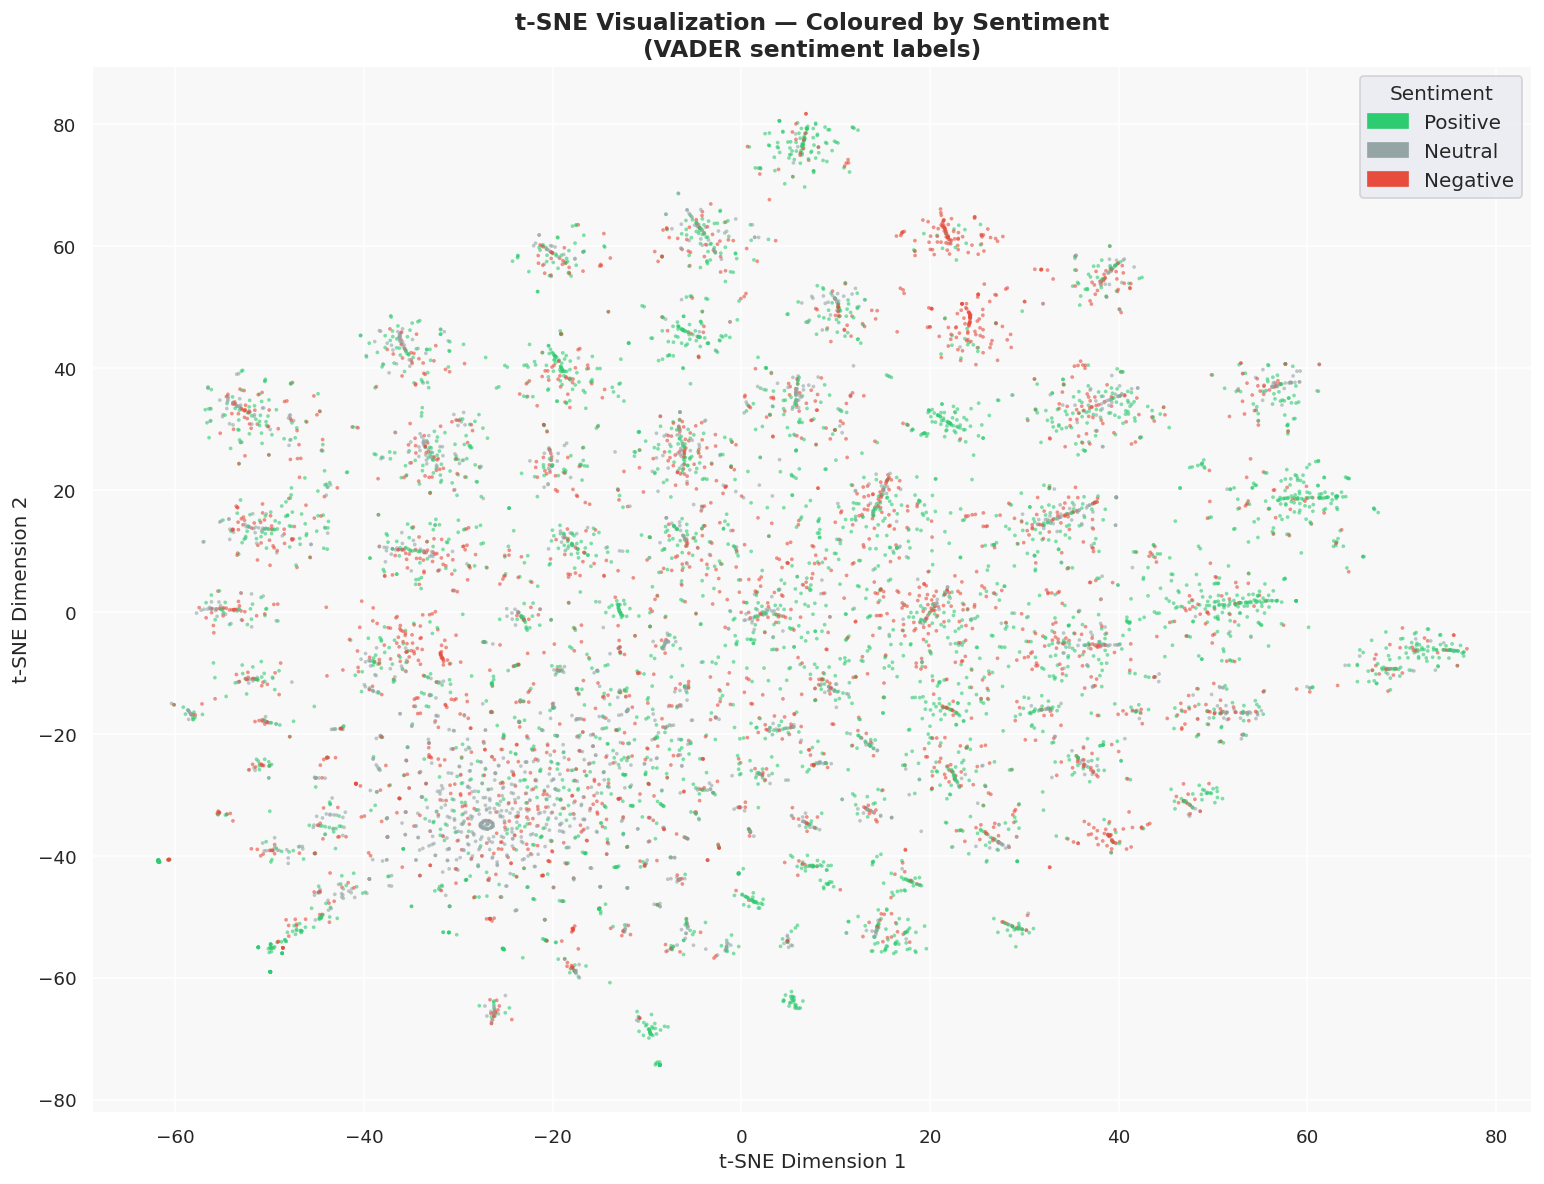

In [ ]:
# ── 8.2 t-SNE coloured by Sentiment ──
sent_palette = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}
sent_colors = df_tsne['sentiment_label'].map(sent_palette).fillna('#95a5a6')

fig, ax = plt.subplots(figsize=(13, 10))
ax.scatter(df_tsne['tsne_x'], df_tsne['tsne_y'], c=sent_colors, s=5, alpha=0.6, linewidths=0)
patches_sent = [mpatches.Patch(color=v, label=k.capitalize()) for k, v in sent_palette.items()]
ax.legend(handles=patches_sent, fontsize=12, title='Sentiment')
ax.set_title('t-SNE Visualization — Coloured by Sentiment\n(VADER sentiment labels)', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_facecolor('#f8f8f8')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DVA_exp8_tsne_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

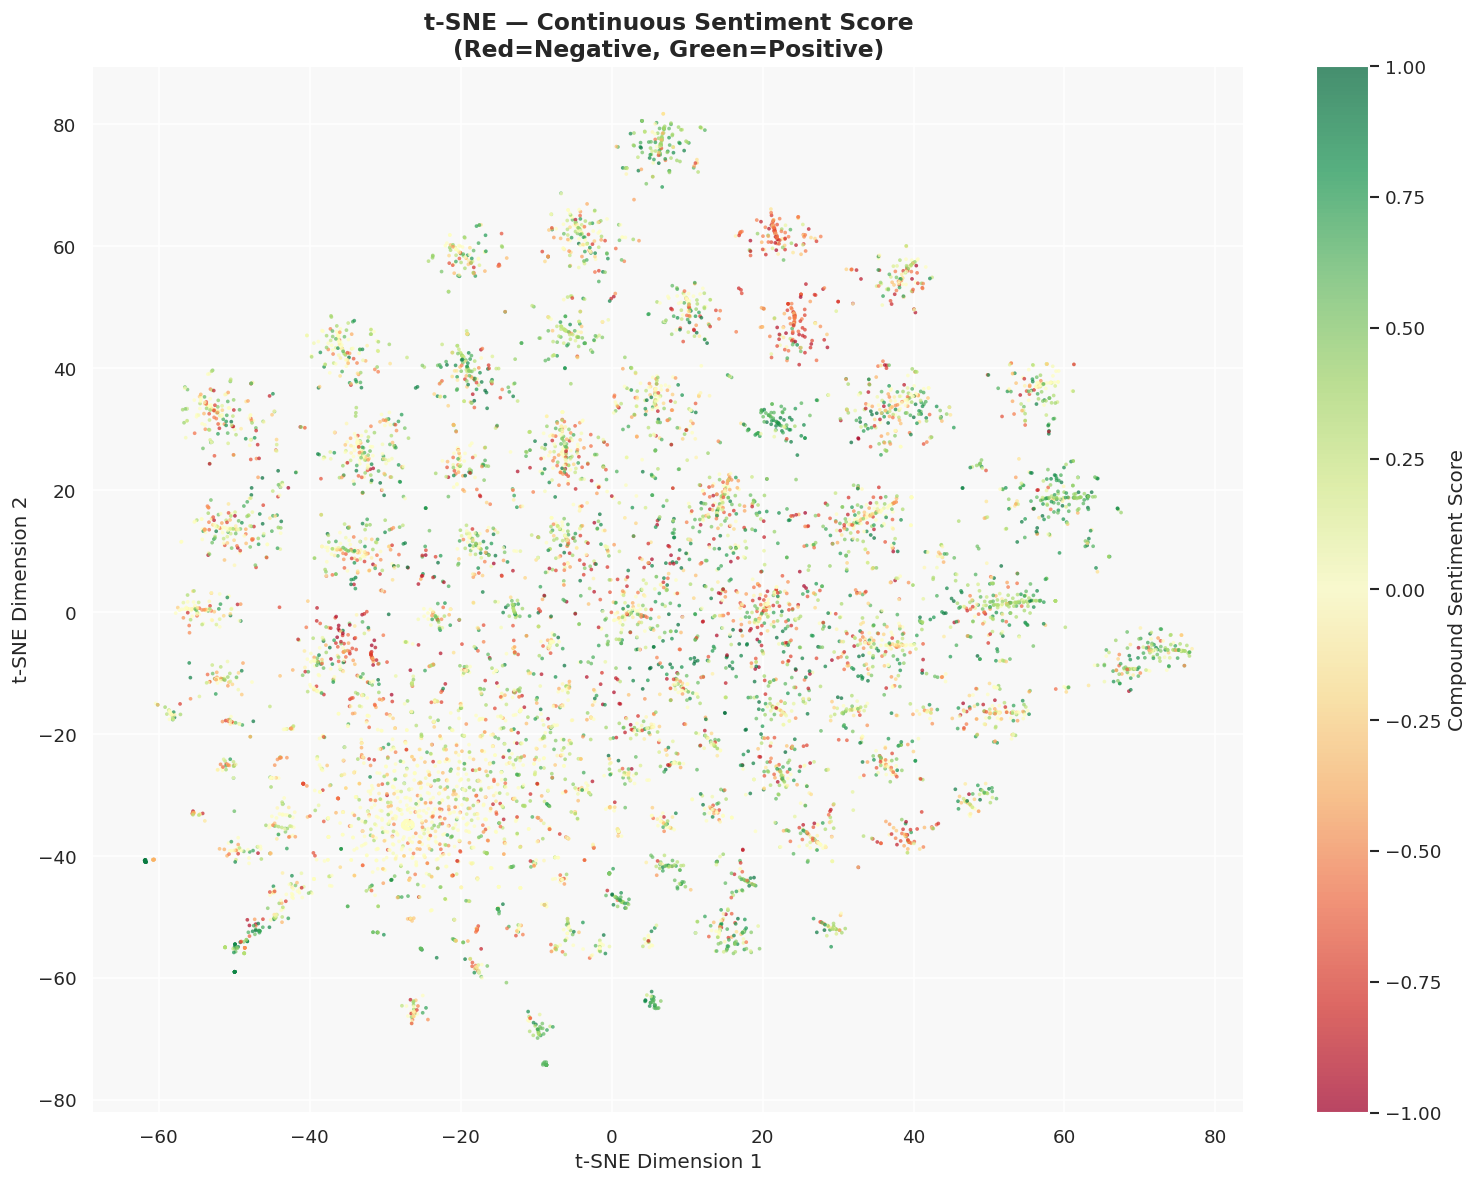

In [ ]:
# ── 8.3 t-SNE coloured by Sentiment Compound Score (continuous) ──
fig, ax = plt.subplots(figsize=(13, 10))
sc = ax.scatter(df_tsne['tsne_x'], df_tsne['tsne_y'],
                c=df_tsne['sentiment_compound'], cmap='RdYlGn',
                s=5, alpha=0.7, linewidths=0, vmin=-1, vmax=1)
plt.colorbar(sc, ax=ax, label='Compound Sentiment Score')
ax.set_title('t-SNE — Continuous Sentiment Score\n(Red=Negative, Green=Positive)', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_facecolor('#f8f8f8')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DVA_exp8_tsne_compound.png', dpi=150, bbox_inches='tight')
plt.show()

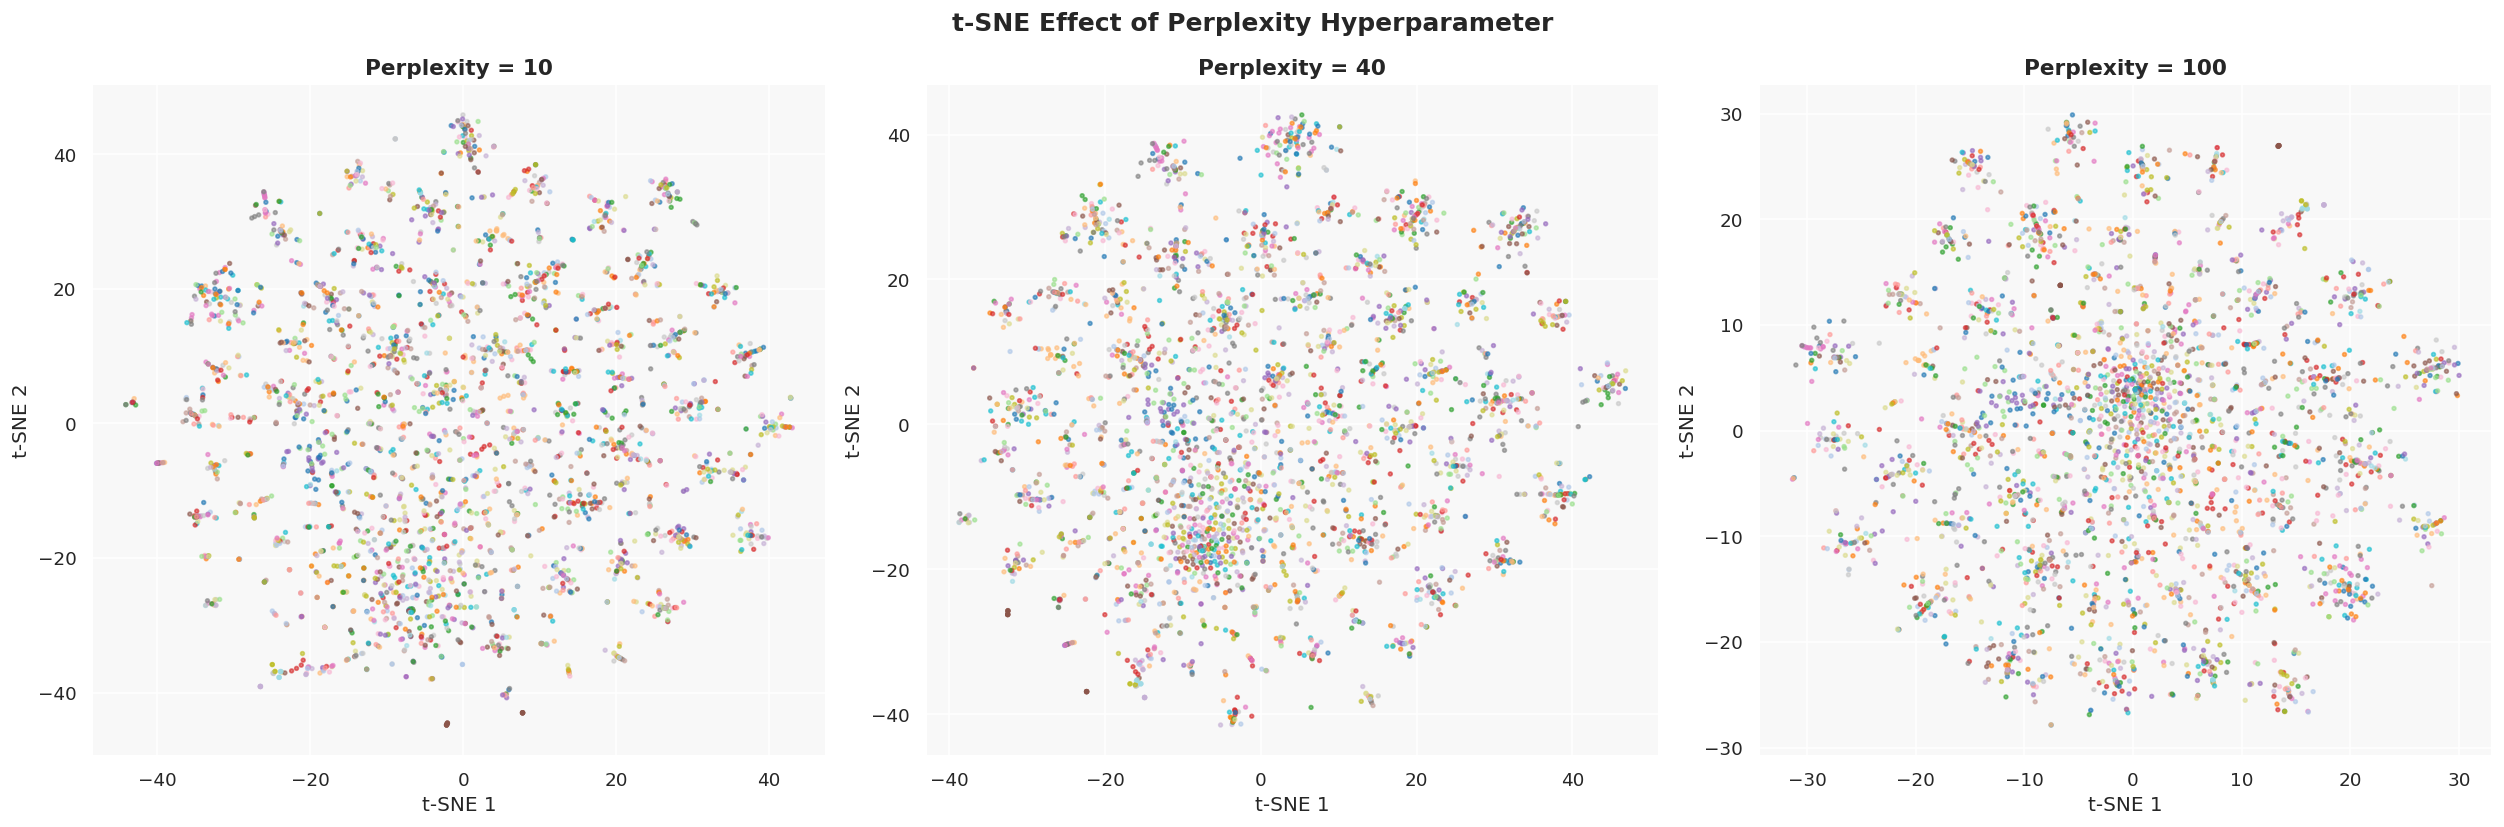

In [ ]:
# ── 8.4 t-SNE at different perplexity values ──
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
perplexities = [10, 40, 100]

for ax, perp in zip(axes, perplexities):
    tsne_p = TSNE(n_components=2, perplexity=perp, n_iter=500, random_state=42, init='pca', learning_rate='auto')
    coords = tsne_p.fit_transform(X_svd[:3000])  # 3k for speed
    if 'subreddit' in df_tsne.columns:
        c = df_tsne['subreddit'].iloc[:3000].map(color_map)
        ax.scatter(coords[:, 0], coords[:, 1], c=c, s=5, alpha=0.6)
    else:
        ax.scatter(coords[:, 0], coords[:, 1], s=5, alpha=0.5)
    ax.set_title(f'Perplexity = {perp}', fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.set_facecolor('#f8f8f8')

fig.suptitle('t-SNE Effect of Perplexity Hyperparameter', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DVA_exp8_tsne_perplexity.png', dpi=150, bbox_inches='tight')
plt.show()

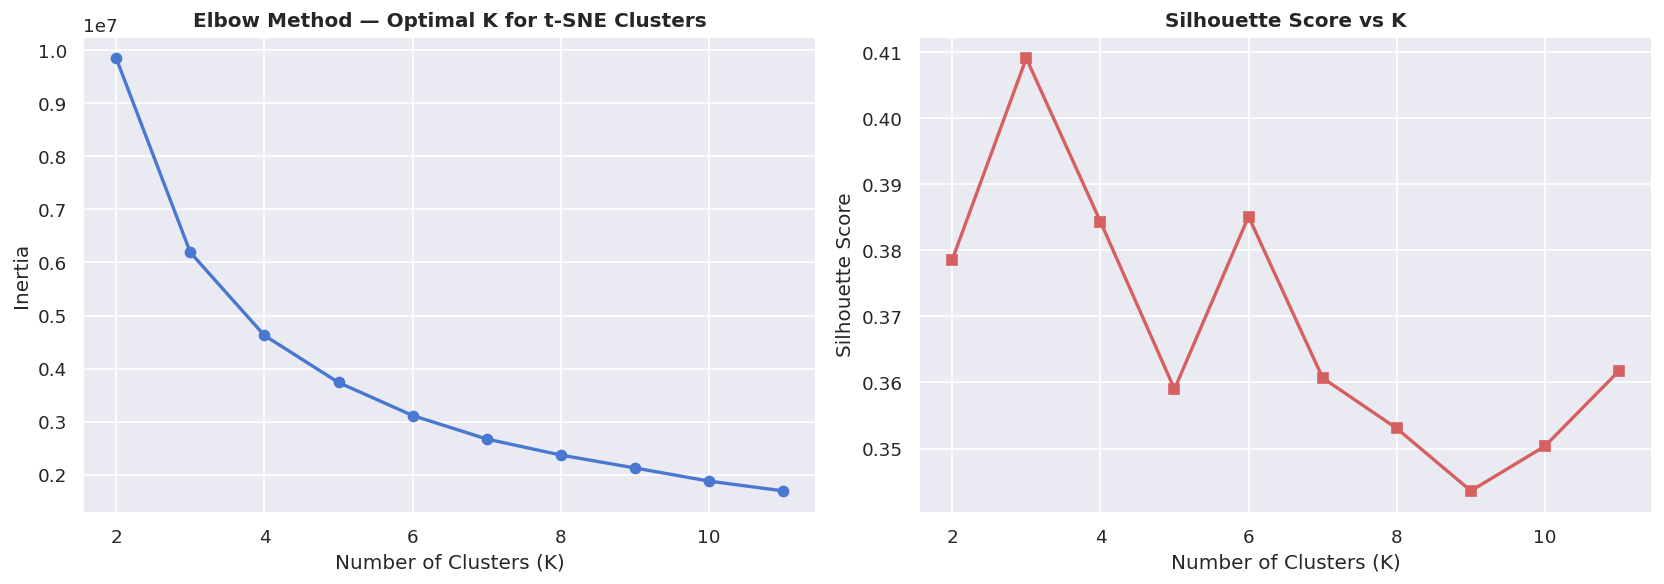

Optimal K (max silhouette): 3


In [ ]:
# ── 8.5 KMeans Clustering on t-SNE Coordinates ──
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Find optimal K using elbow + silhouette
K_range = range(2, 12)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_tsne)
    inertias.append(km.inertia_)
    if k >= 2:
        silhouettes.append(silhouette_score(X_tsne, km.labels_, sample_size=3000))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method — Optimal K for t-SNE Clusters', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

axes[1].plot(list(K_range), silhouettes, 'rs-', linewidth=2)
axes[1].set_title('Silhouette Score vs K', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DVA_exp8_tsne_elbow.png', dpi=150)
plt.show()

optimal_k = list(K_range)[np.argmax(silhouettes)]
print(f'Optimal K (max silhouette): {optimal_k}')

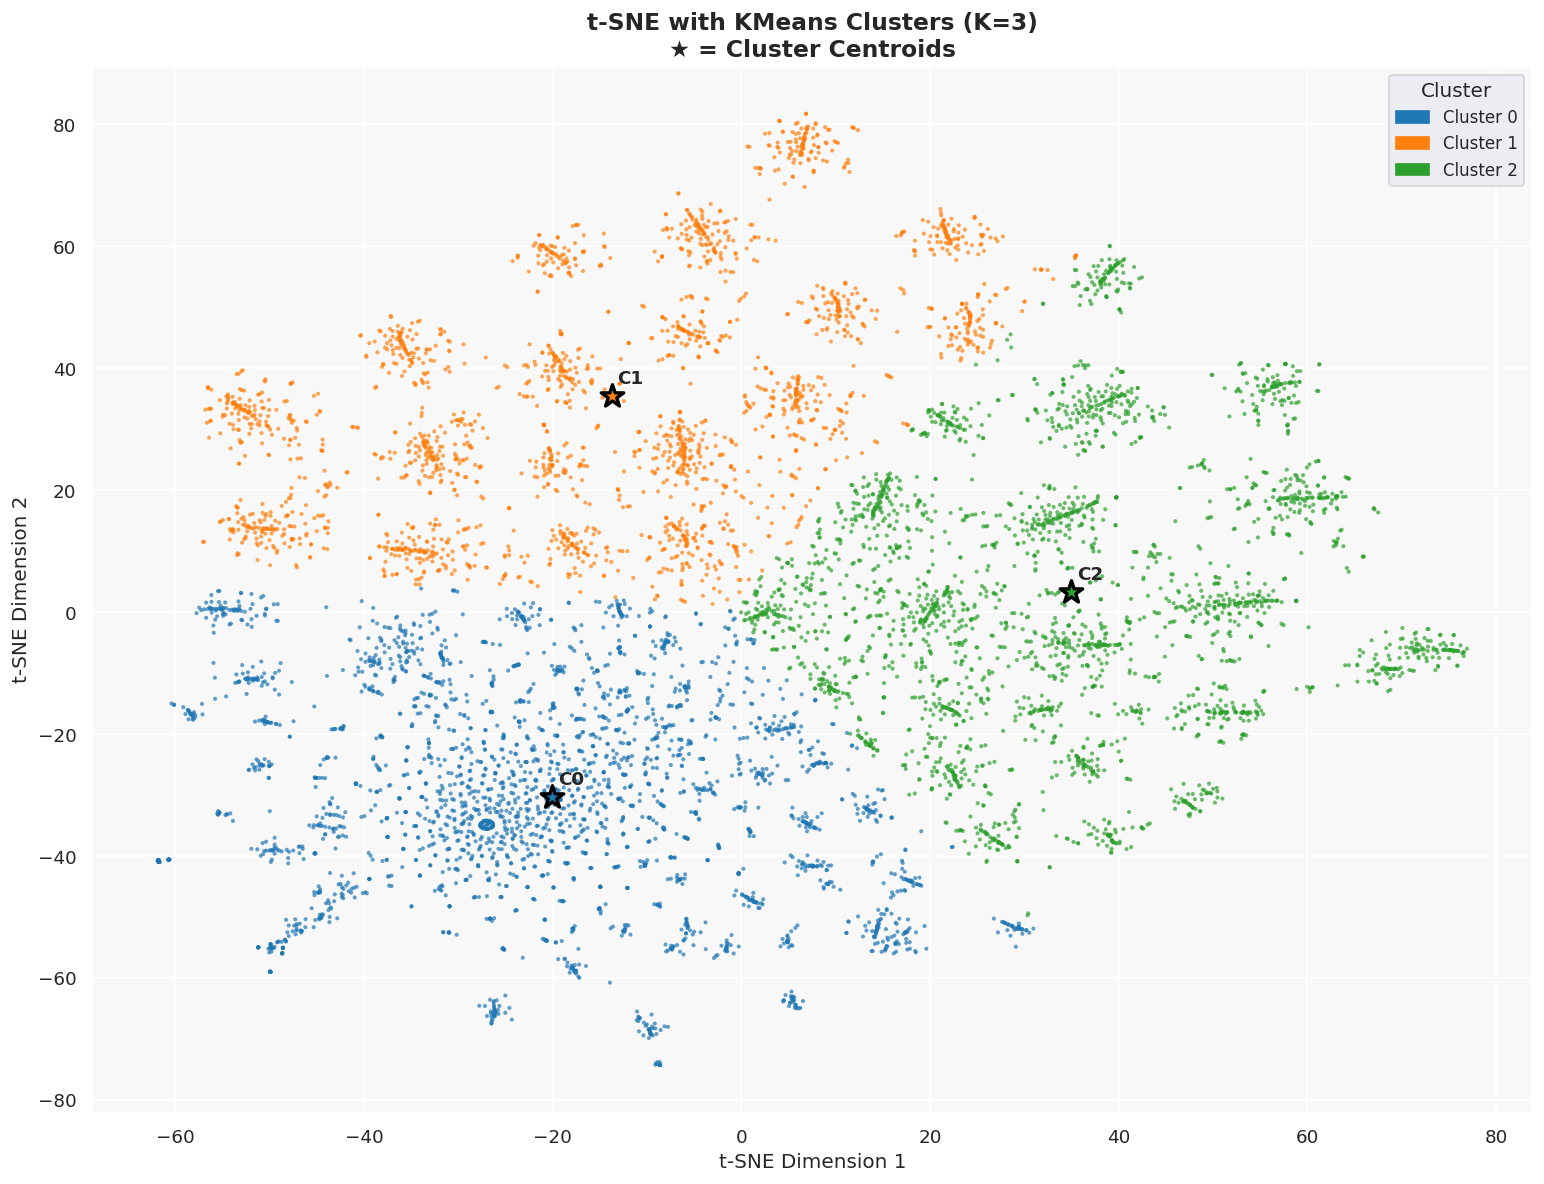

In [ ]:
# Apply KMeans with optimal K
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_tsne['cluster'] = km_final.fit_predict(X_tsne)

# Plot t-SNE coloured by cluster
cluster_palette = sns.color_palette('tab10', optimal_k)
cluster_colors = df_tsne['cluster'].map(dict(enumerate(cluster_palette)))

fig, ax = plt.subplots(figsize=(13, 10))
scatter = ax.scatter(df_tsne['tsne_x'], df_tsne['tsne_y'],
                     c=cluster_colors, s=6, alpha=0.7, linewidths=0)
# Plot cluster centroids
for i in range(optimal_k):
    mask = df_tsne['cluster'] == i
    cx, cy = df_tsne.loc[mask, 'tsne_x'].mean(), df_tsne.loc[mask, 'tsne_y'].mean()
    ax.scatter(cx, cy, s=200, c=[cluster_palette[i]], edgecolors='black', linewidths=2, zorder=5, marker='*')
    ax.annotate(f'C{i}', (cx, cy), fontsize=11, fontweight='bold', ha='center',
                xytext=(cx+2, cy+2))
patches_c = [mpatches.Patch(color=cluster_palette[i], label=f'Cluster {i}') for i in range(optimal_k)]
ax.legend(handles=patches_c, fontsize=10, title='Cluster')
ax.set_title(f't-SNE with KMeans Clusters (K={optimal_k})\n★ = Cluster Centroids', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1'); ax.set_ylabel('t-SNE Dimension 2')
ax.set_facecolor('#f8f8f8')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DVA_exp8_tsne_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 8.6 Top words per cluster ──
print('Top terms per cluster:')
for c in range(optimal_k):
    cluster_texts = df_tsne.loc[df_tsne['cluster'] == c, 'clean_text']
    all_words = ' '.join(cluster_texts).split()
    top_words_c = Counter(all_words).most_common(10)
    print(f'  Cluster {c}: {[w for w, _ in top_words_c]}')

Top terms per cluster:
  Cluster 0: ['post', 'need', 'even', 'please', 'karma', 'make', 'comment', 'message', 'also', 'much']
  Cluster 1: ['one', 'time', 'year', 'see', 'like', 'got', 'right', 'still', 'get', "that's"]
  Cluster 2: ['like', 'people', 'would', 'get', 'think', 'know', 'good', 'make', 'game', 'way']
